# Data visualisation

## Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scripts.hourly_forecasting.data_preparation.data_pipeline import prepare_data_forecasting
from scripts.hourly_forecasting.data_preparation.data_cleaning import show_na, plot_na, missing_data_report
from scripts.hourly_forecasting.data_preparation.feature_engineering import construct_features, discard_features
from scripts.hourly_forecasting.data_preparation.data_visualisation import moving_average_plot, diff_lag_plot, cross_lag_plot, cross_diff_lag_plot, monthly_averages, weekday_averages, hourly_averages, weekday_per_month, hourly_per_month

C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\data_visualisation.py:136: SyntaxWarning: invalid escape sequence '\D'
  plot(kind="scatter", x=f"{var_x}", y=f"{var_y}", title=f"Cross differenced lag plot: $\Delta$ {var_x} and $\Delta$ {var_y}", xlabel=f" $\Delta$ {var_x} (t + {lag_x})", ylabel=f"$\Delta$ {var_y} (t + {lag_y})");
C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\data_visualisation.py:136: SyntaxWarning: invalid escape sequence '\D'
  plot(kind="scatter", x=f"{var_x}", y=f"{var_y}", title=f"Cross differenced lag plot: $\Delta$ {var_x} and $\Delta$ {var_y}", xlabel=f" $\Delta$ {var_x} (t + {lag_x})", ylabel=f"$\Delta$ {var_y} (t + {lag_y})");
C:\Users\ml4\Desktop\Projects\Repos\EnergyForecasting\src\scripts\hourly_forecasting\data_preparation\data_visualisation.py:136: SyntaxWarning: invalid escape sequence '\D'
  plot(kind="scatter", x=f"{var_x}", y=f"{var_y}", titl

## Load data

In [3]:
data_path = "../../../data/Hourly_Electricity_Demand_Gen_Weather_Spain/{}.csv";

energy_data_path = data_path.format("energy_dataset");
weather_data_path = data_path.format("weather_features");

In [4]:
energy_data = pd.read_csv(energy_data_path);
weather_data = pd.read_csv(weather_data_path);

## Run data pipeline

In [5]:
data = prepare_data_forecasting(energy_data, weather_data);

In [6]:
pd.set_option("display.max_columns", 100);

In [7]:
data.head()

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual,tz_offset,tempValencia,temp_minValencia,temp_maxValencia,pressureValencia,humidityValencia,wind_speedValencia,wind_degValencia,rain_1hValencia,rain_3hValencia,snow_3hValencia,clouds_allValencia,weather_idValencia,weather_mainValencia,weather_descriptionValencia,weather_iconValencia,tempMadrid,temp_minMadrid,temp_maxMadrid,pressureMadrid,humidityMadrid,wind_speedMadrid,wind_degMadrid,rain_1hMadrid,rain_3hMadrid,snow_3hMadrid,clouds_allMadrid,weather_idMadrid,weather_mainMadrid,weather_descriptionMadrid,weather_iconMadrid,tempBilbao,temp_minBilbao,temp_maxBilbao,pressureBilbao,humidityBilbao,wind_speedBilbao,wind_degBilbao,rain_1hBilbao,rain_3hBilbao,snow_3hBilbao,clouds_allBilbao,weather_idBilbao,weather_mainBilbao,weather_descriptionBilbao,weather_iconBilbao,temp Barcelona,temp_min Barcelona,temp_max Barcelona,pressure Barcelona,humidity Barcelona,wind_speed Barcelona,wind_deg Barcelona,rain_1h Barcelona,rain_3h Barcelona,clouds_all Barcelona,weather_id Barcelona,weather_main Barcelona,weather_description Barcelona,weather_icon Barcelona,tempSeville,temp_minSeville,temp_maxSeville,pressureSeville,humiditySeville,wind_speedSeville,wind_degSeville,rain_1hSeville,rain_3hSeville,clouds_allSeville,weather_idSeville,weather_mainSeville,weather_descriptionSeville,weather_iconSeville
2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,17.0,6436.0,26118.0,25385.0,50.10,65.41,1.0,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n,269.657312,269.657312,269.657312,1036,97,0,226,0.0,0.0,0.0,0,800,clear,sky is clear,01,281.625,281.625,281.625,1035,100,7,58,0.0,0.0,0,800,clear,sky is clear,01n,273.375,273.375,273.375,1039,75,1,21,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,16.0,5856.0,24934.0,24382.0,48.10,64.92,1.0,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n,269.763500,269.763500,269.763500,1035,97,0,229,0.0,0.0,0.0,0,800,clear,sky is clear,01,281.625,281.625,281.625,1035,100,7,58,0.0,0.0,0,800,clear,sky is clear,01n,273.375,273.375,273.375,1039,75,1,21,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,8.0,5454.0,23515.0,22734.0,47.33,64.48,1.0,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n,269.251688,269.251688,269.251688,1036,97,1,224,0.0,0.0,0.0,0,800,clear,sky is clear,01,281.286,281.286,281.286,1036,100,7,48,0.0,0.0,0,800,clear,sky is clear,01n,274.086,274.086,274.086,1039,71,3,27,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,2.0,5151.0,22642.0,21286.0,42.27,59.32,1.0,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n,269.203344,269.203344,269.203344,1035,97,1,225,0.0,0.0,0.0,0,800,clear,sky is clear,01,281.286,281.286,281.286,1036,100,7,48,0.0,0.0,0,800,clear,sky is clear,01n,274.086,274.086,274.086,1039,71,3,27,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 03:00

## Inspect missing values

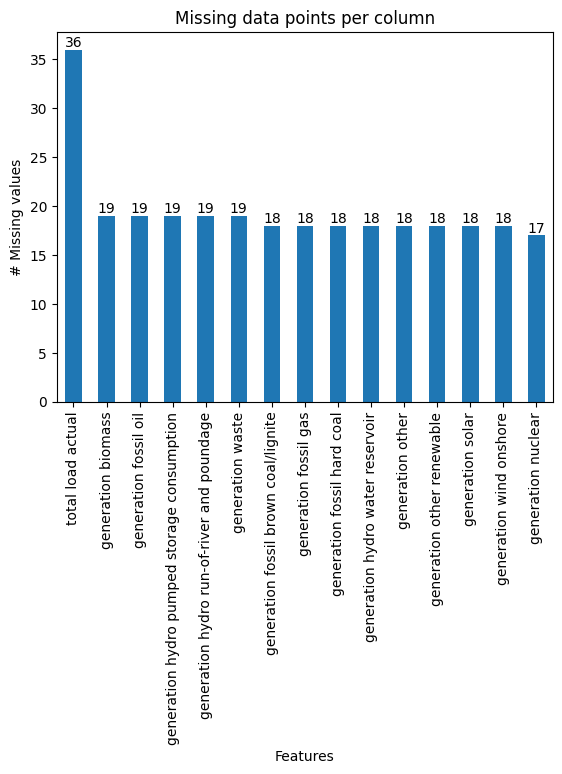

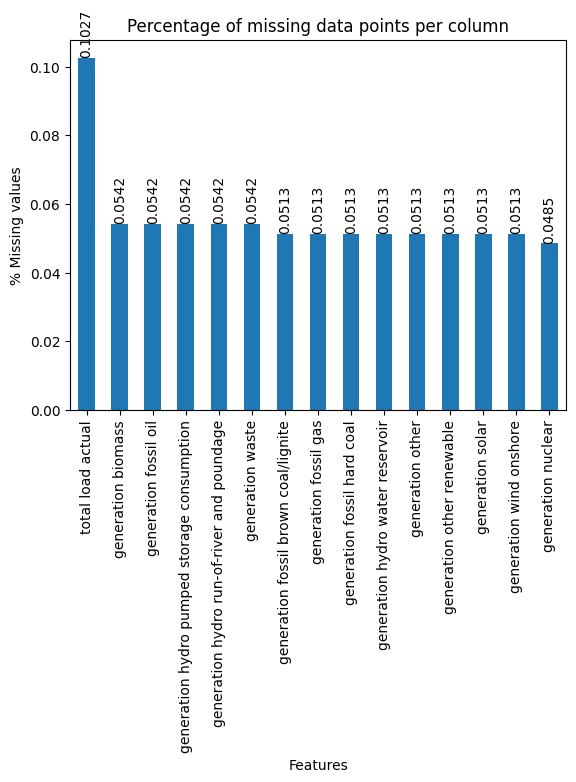

In [8]:
missing_data_report(data);

In [9]:
show_na(data, "total load actual").shape[0]

36

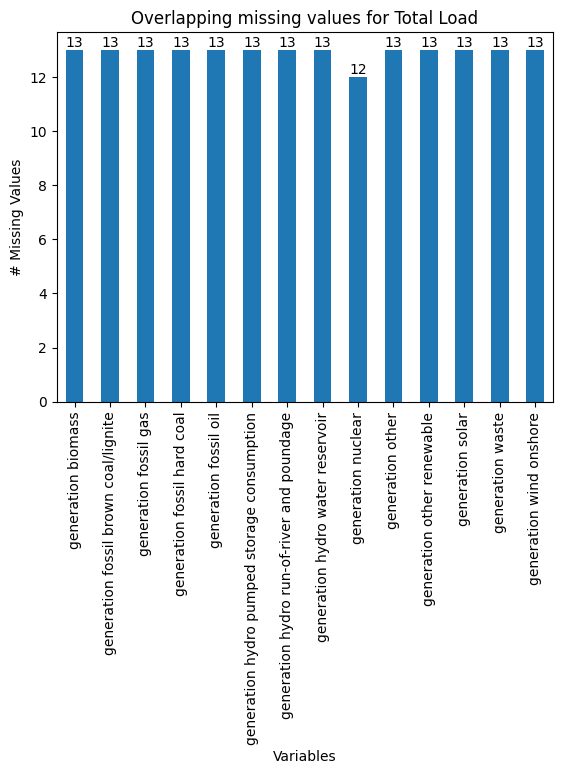

In [10]:
overlapping_na = show_na(data, "total load actual").isna().sum();
overlapping_na = overlapping_na.loc[overlapping_na > 0].drop("total load actual");
ax = overlapping_na.plot(kind="bar", title="Overlapping missing values for Total Load", xlabel="Variables", ylabel="# Missing Values");
ax.bar_label(ax.containers[0]);
plt.show();

### Preliminary remarks

- A significant portion of all missing values occur in timestamps where the total load is missing. This may indicate that these timestamps may correspond to a generalised loss of data, although further inquiries would be required to determine whether its cause was a grid failure. 

- Furthermore, for many data points where the total load is missing, there exist many generation variables whose values are known, meaning they can be used in a data imputation procedure if so required.

- Even though the total load is the most affected variable in terms of missing values, these ammount to only 0.1 % of all records. Therefore, data imputation is not only feasible, but also desirable, as the data will not be significantly distorted and the series will not have any "holes" in them.

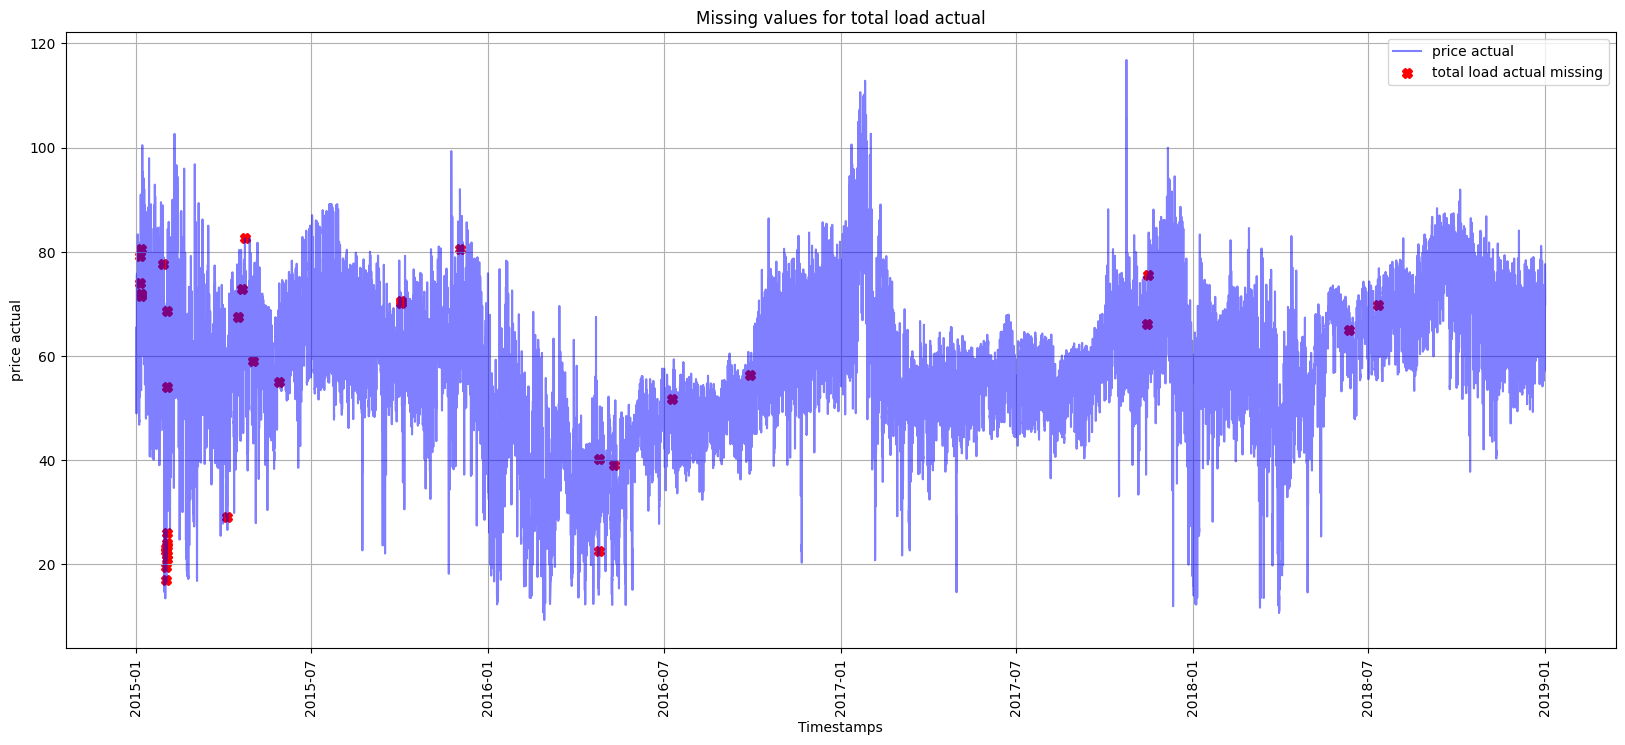

In [11]:
plot_na(data, "price actual", "total load actual", (20, 8));

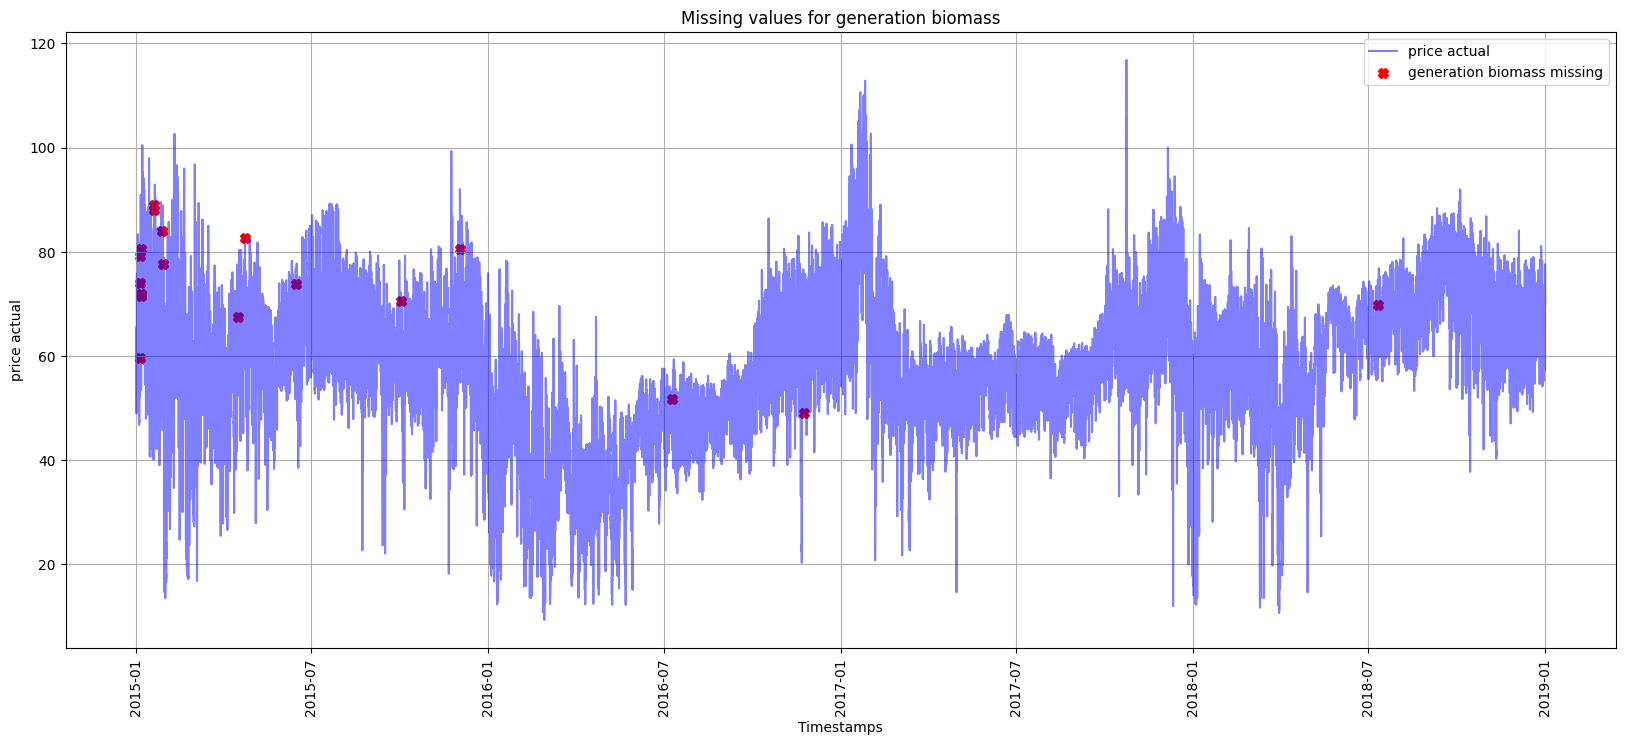

In [12]:
plot_na(data, "price actual", "generation biomass", (20, 8));

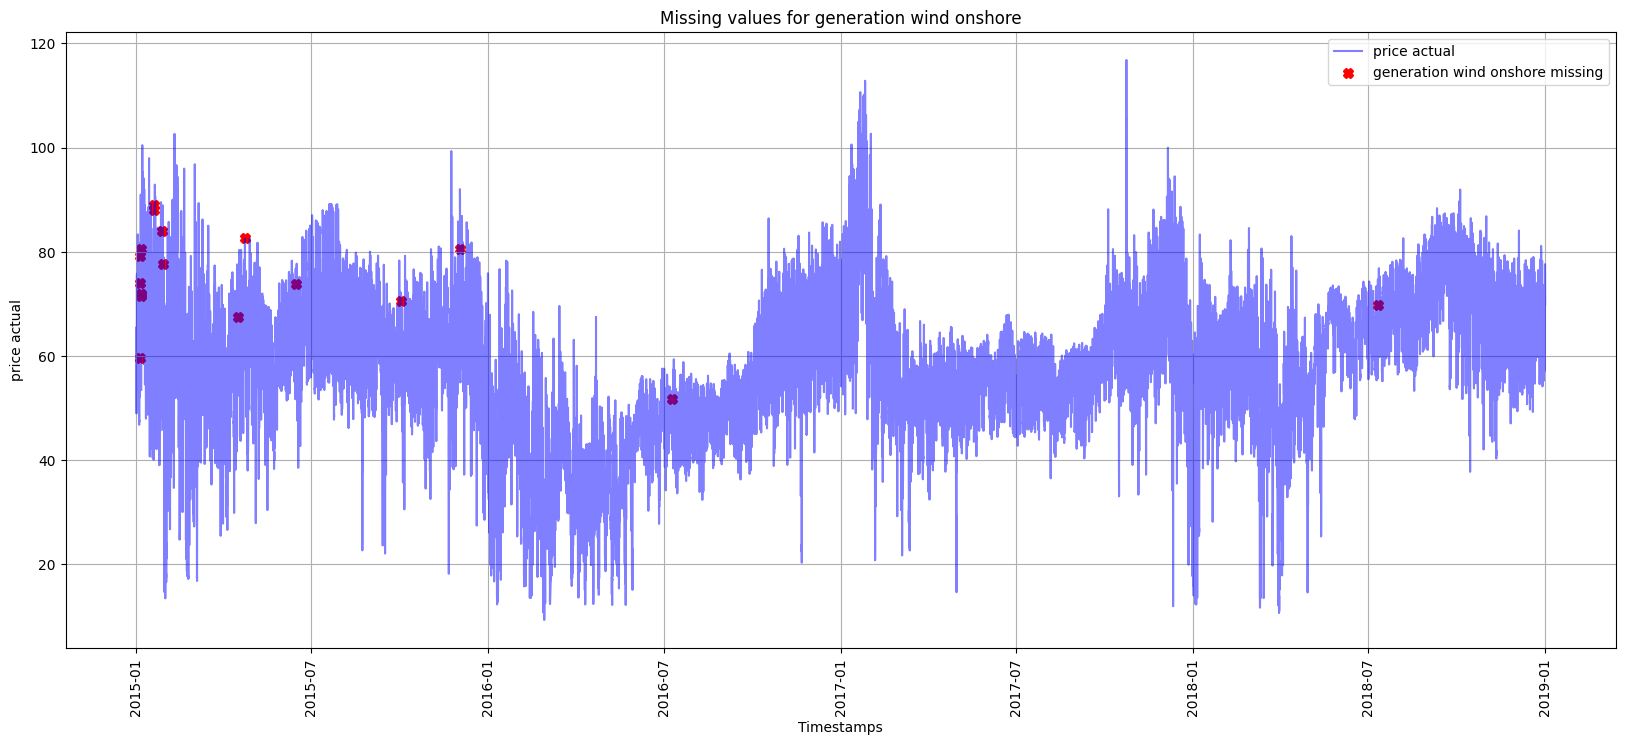

In [13]:
plot_na(data, "price actual", "generation wind onshore", (20, 8));

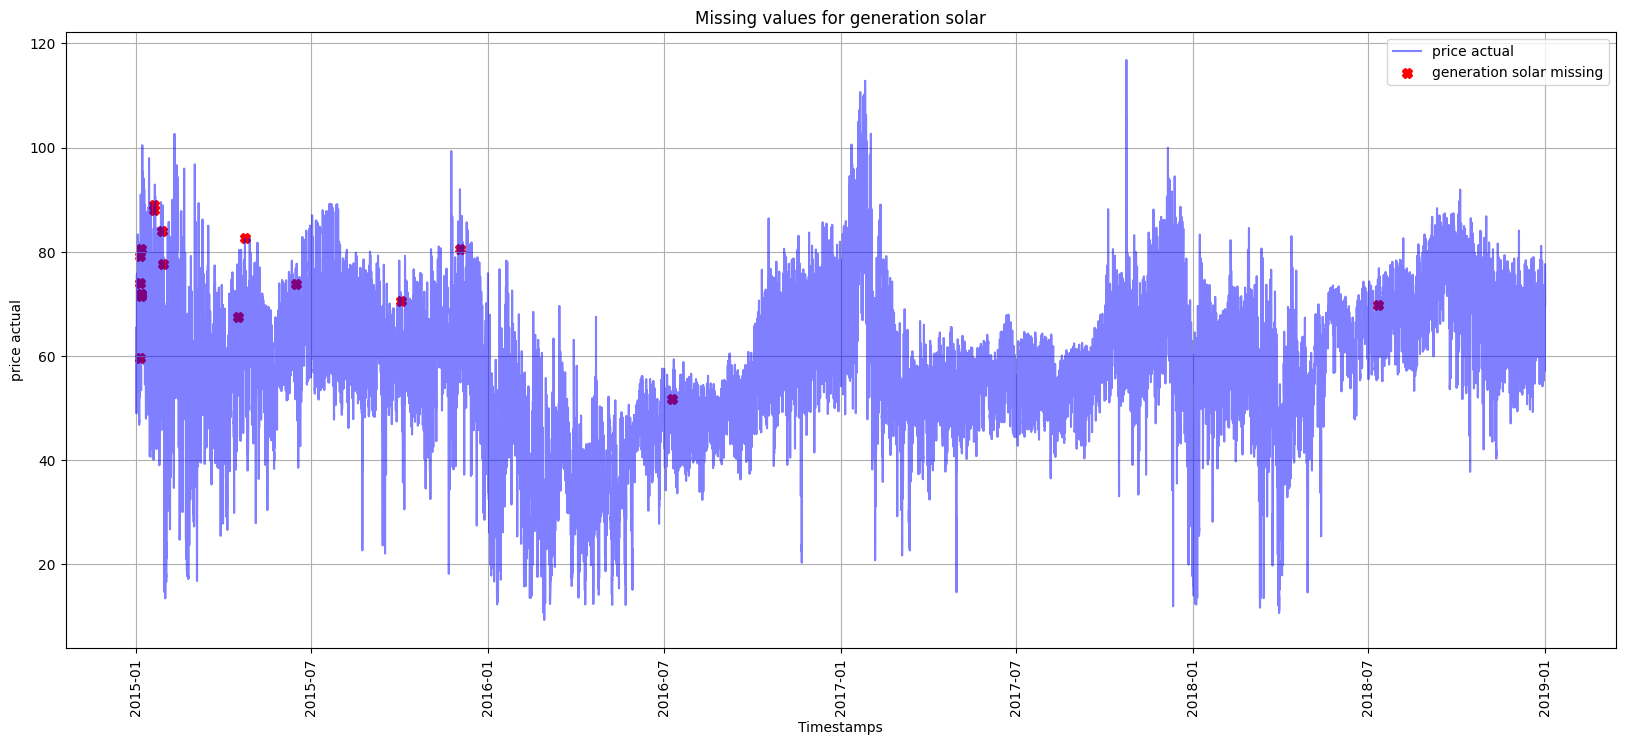

In [14]:
plot_na(data, "price actual", "generation solar", (20, 8));

### More preliminary remarks

- The missing data points seem to be fairly scattered, although they are far more numerous early on.

- A common time-aware data imputation procedure, such as a moving average, will most likely suffice under these conditions. This, however, will be the subject of another notebook.

## Data visualisation

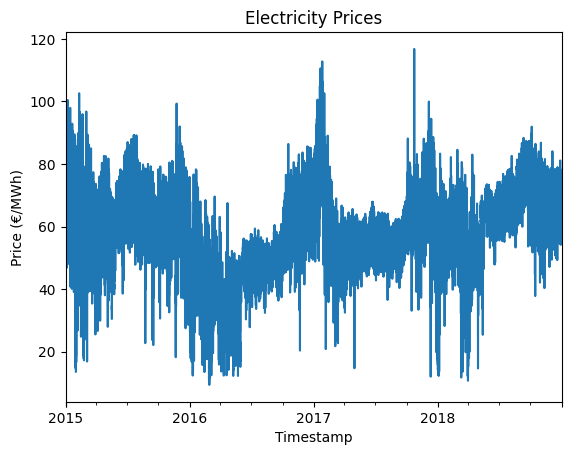

In [15]:
data["price actual"].plot(kind="line", xlabel="Timestamp", ylabel="Price (€/MWh)", title="Electricity Prices");

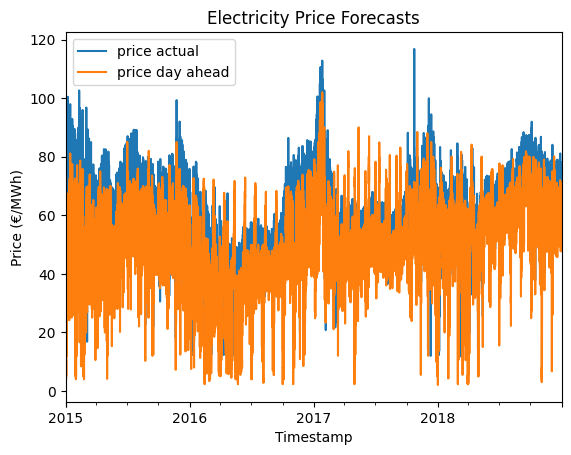

In [16]:
data[["price actual", "price day ahead"]].plot(kind="line", xlabel="Timestamp", ylabel="Price (€/MWh)", title="Electricity Price Forecasts");

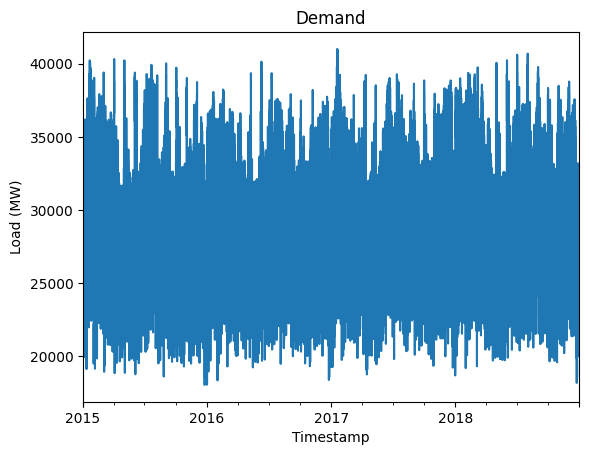

In [17]:
data["total load actual"].plot(kind="line", xlabel="Timestamp", ylabel="Load (MW)", title="Demand");

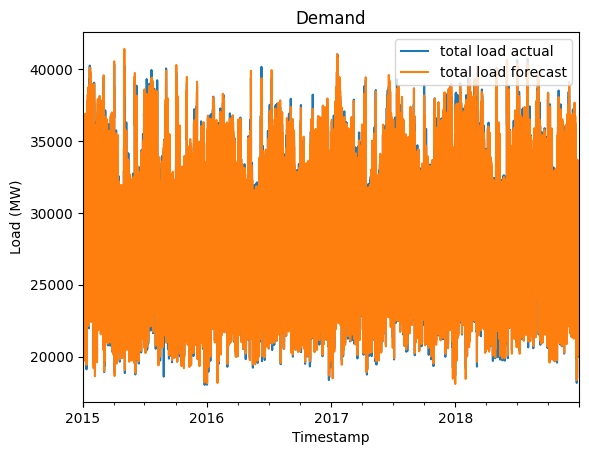

In [18]:
data[["total load actual", "total load forecast"]].plot(kind="line", xlabel="Timestamp", ylabel="Load (MW)", title="Demand");

### Preliminary remarks

- The electricity price series is characterised by a few significant spikes and a clear cyclical component (which may be irregular);

- From this plot, it is unclear whether there is a strong trend in electricity prices. A dedicated analysis will have to be conducted;

- The day ahead forecast is biased, as it consistently underestimates the true price. Additionally, it does seem to predict a spike in price when none occurs far too often;

- The load / demand time series seems to be less spiky, and at least one seasonal component is clearly present. There seems to be no trend in this series;

- The load day ahead prediction is much more accurate than its price counterpart.

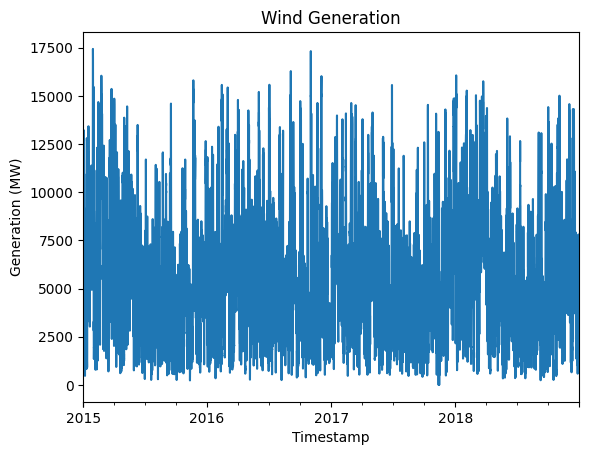

In [19]:
data["generation wind onshore"].plot(kind="line", xlabel="Timestamp", ylabel="Generation (MW)", title="Wind Generation");

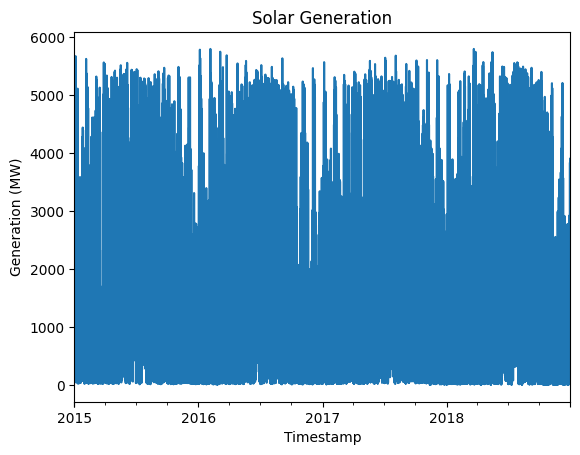

In [20]:
data["generation solar"].plot(kind="line", xlabel="Timestamp", ylabel="Generation (MW)", title="Solar Generation");

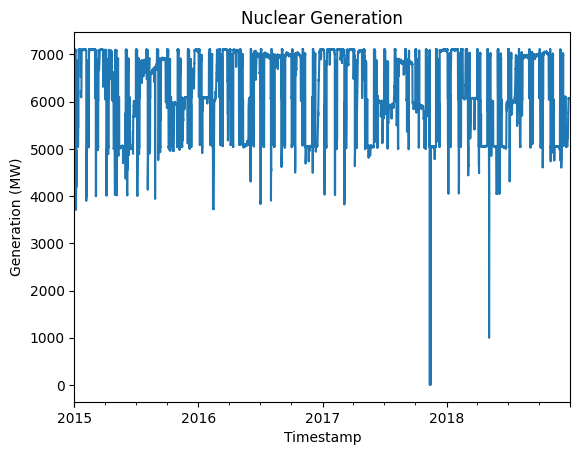

In [21]:
data["generation nuclear"].plot(kind="line", xlabel="Timestamp", ylabel="Generation (MW)", title="Nuclear Generation");

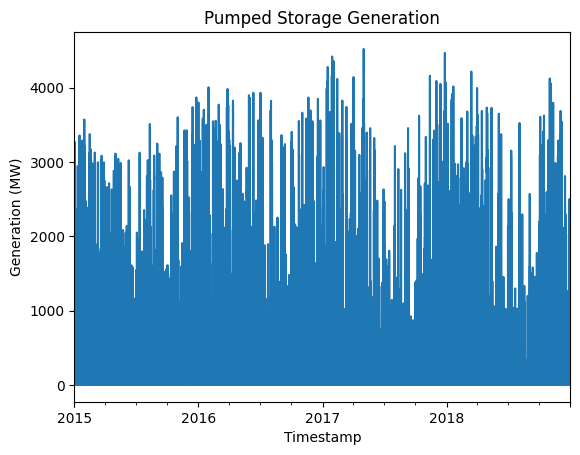

In [22]:
data["generation hydro pumped storage consumption"].plot(kind="line", xlabel="Timestamp", ylabel="Generation (MW)", title="Pumped Storage Generation");

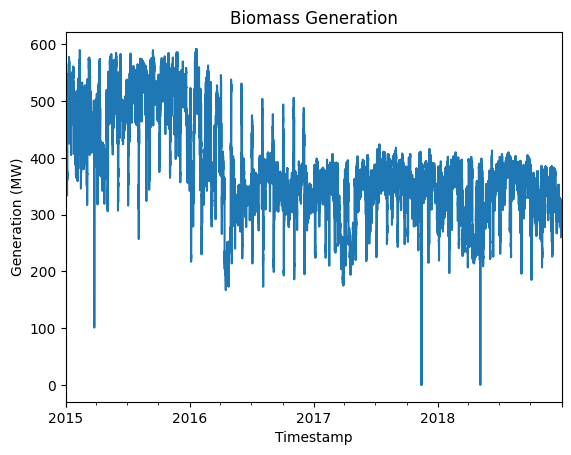

In [23]:
data["generation biomass"].plot(kind="line", xlabel="Timestamp", ylabel="Generation (MW)", title="Biomass Generation");

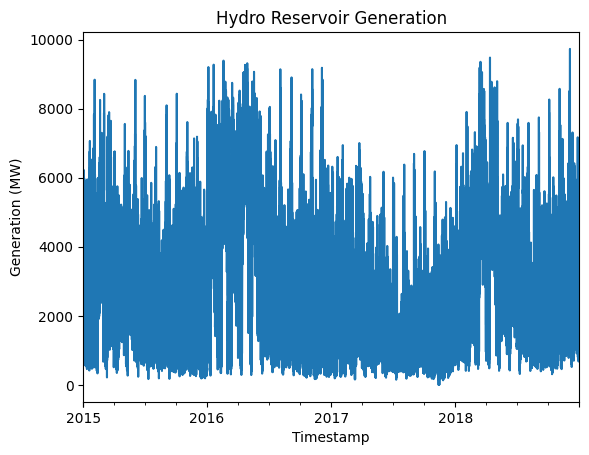

In [24]:
data["generation hydro water reservoir"].plot(kind="line", xlabel="Timestamp", ylabel="Generation (MW)", title="Hydro Reservoir Generation");

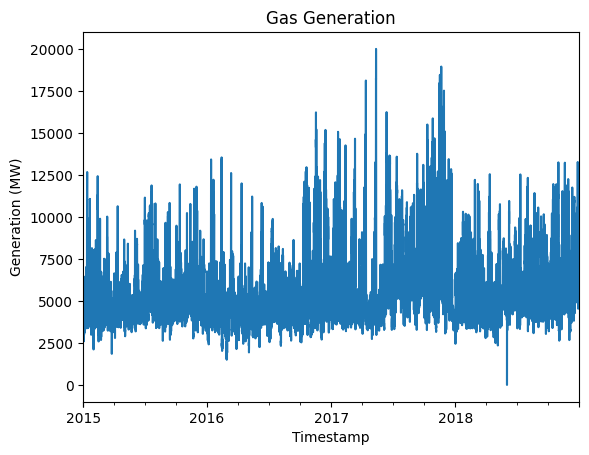

In [25]:
data["generation fossil gas"].plot(kind="line", xlabel="Timestamp", ylabel="Generation (MW)", title="Gas Generation");

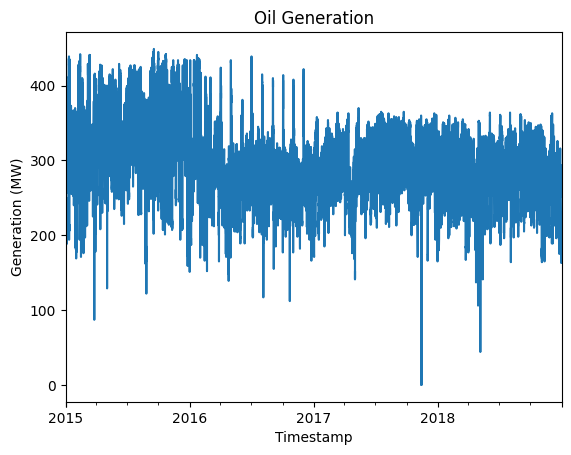

In [26]:
data["generation fossil oil"].plot(kind="line", xlabel="Timestamp", ylabel="Generation (MW)", title="Oil Generation");

### More preliminary remarks

- As one would expect, there are high-amplitude oscillations in wind and solar generation. Both series exhibit clear seasonal patterns;

- A mean shift in biomass generation seems to have occured around 2016;

- For the most part, nuclear generation remains stable. A seasonal pattern is discernible nonetheless;

- Hydro generation series seem to exhibit seasonal patterns. No clear trend is visible;

- Gas generation seems to remain stable apart from a few spikes. These are, most likely, a result of momentary shortages in wind or solar generation and / or increases in demand;

- Oil generation is similar to gas generation, but a mean shift seems to have taken place in early 2016.

## Specialised visualisation techniques

In [27]:
data = construct_features(data);
data = discard_features(data);

In [28]:
data

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual,tempValencia,pressureValencia,humidityValencia,wind_speedValencia,wind_degValencia,rain_1hValencia,rain_3hValencia,snow_3hValencia,clouds_allValencia,tempMadrid,pressureMadrid,humidityMadrid,wind_speedMadrid,wind_degMadrid,rain_1hMadrid,rain_3hMadrid,snow_3hMadrid,clouds_allMadrid,tempBilbao,pressureBilbao,humidityBilbao,wind_speedBilbao,wind_degBilbao,rain_1hBilbao,rain_3hBilbao,snow_3hBilbao,clouds_allBilbao,temp Barcelona,pressure Barcelona,humidity Barcelona,wind_speed Barcelona,wind_deg Barcelona,rain_1h Barcelona,rain_3h Barcelona,clouds_all Barcelona,tempSeville,pressureSeville,humiditySeville,wind_speedSeville,wind_degSeville,rain_1hSeville,rain_3hSeville,clouds_allSeville,weekday,hour,total_gen,stable_renewable_gen,renewable_gen,excess_demand,demand_supply_ratio,coverage,excess_coverage,renewables_share,renewable_utilisation_ratio,stable_renewable_utilisation_ratio,renewable_coverage,stable_renewable_coverage,excess_renewable_coverage,excess_stable_renewable_coverage,reserve_margin,capacity_utilisation,renewable_margin,renewable_capacity_utilisation,stable_renewable_margin,stable_renewable_capacity_utilisation
2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,17.0,6436.0,26118.0,25385.0,50.10,65.41,270.475,1001,77,1,62,0.0,0.0,0.0,0,267.325,971,63,1,309,0.0,0.0,0.0,0,269.657312,1036,97,0,226,0.0,0.0,0.0,0,281.625,1035,100,7,58,0.0,0.0,0,273.375,1039,75,1,21,0.0,0.0,0,2,24,28251.0,2762.0,10883.0,-2866.0,0.898552,2.976364,-26.362526,0.385225,0.200379,0.120024,1.710813,0.797715,-15.153175,-7.065597,78421.0,0.755457,28927.0,0.532608,-2373.0,-0.103120
2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,16.0,5856.0,24934.0,24382.0,48.10,64.92,270.475,1001,77,1,62,0.0,0.0,0.0,0,267.325,971,63,1,309,0.0,0.0,0.0,0,269.763500,1035,97,0,229,0.0,0.0,0.0,0,281.625,1035,100,7,58,0.0,0.0,0,273.375,1039,75,1,21,0.0,0.0,0,3,1,27818.0,2578.0,10171.0,-3436.0,0.876483,3.116561,-22.115250,0.365627,0.187270,0.112029,1.810393,0.838077,-12.846624,-5.947031,79424.0,0.765120,29930.0,0.551075,-1370.0,-0.059534
2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,8.0,5454.0,23515.0,22734.0,47.33,64.48,269.686,1002,78,0,23,0.0,0.0,0.0,0,266.186,971,64,1,273,0.0,0.0,0.0,0,269.251688,1036,97,1,224,0.0,0.0,0.0,0,281.286,1036,100,7,48,0.0,0.0,0,274.086,1039,71,3,27,0.0,0.0,0,3,2,26796.0,2535.0,9663.0,-4062.0,0.848410,3.387437,-18.958641,0.360614,0.177916,0.110160,1.963975,0.900721,-10.991876,-5.041113,81072.0,0.780995,31578.0,0.581418,278.0,0.012081
2015-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,2.0,5151.0,22642.0,21286.0,42.27,59.32,269.686,1002,78,0,23,0.0,0.0,0.0,0,266.186,971,64,1,273,0.0,0.0,0.0,0,269.203344,1035,97,1,225,0.0,0.0,0.0,0,281.286,1036,100,7,48,0.0,0.0,0,274.086,1039,71,3,27,0.0,0.0,0,3,3,25223.0,2282.0,9148.0,-3937.0,0.843912,3.691769,-19.960122,0.362685,0.168434,0.099166,2.121770,0.973880,-11.471679,-5.265431,82520.0,0.794944,33026.0,0.608079,1726.0,0.075004
2015-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,9.0,4861.0,21785.0,20264.0,38.41,56.04,269.686,1002,78,0,23,0.0,0.0,0.0,0,266.186,971,64,1,273,0.0,0.0,0.0,0,269.485500,1035,97,1,221,0.0,0.0,0.0,0,281.286,1036,100,7,48,0.0,0.0,0,274.086,1039,71,3,27,0.0,0.0,0,3,4,24620.0,2546.0,9093.0,-

In [29]:
data.index.to_series().dt.month_name().unique()

array(['December', 'January', 'February', 'March', 'April', 'May', 'June',
       'July', 'August', 'September', 'October', 'November'], dtype=object)

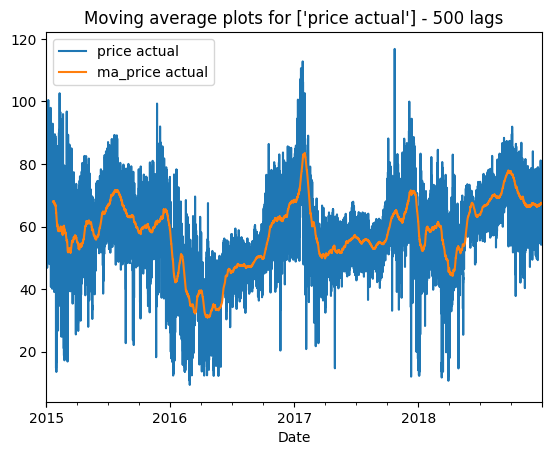

In [30]:
moving_average_plot(data, ["price actual"], 500);

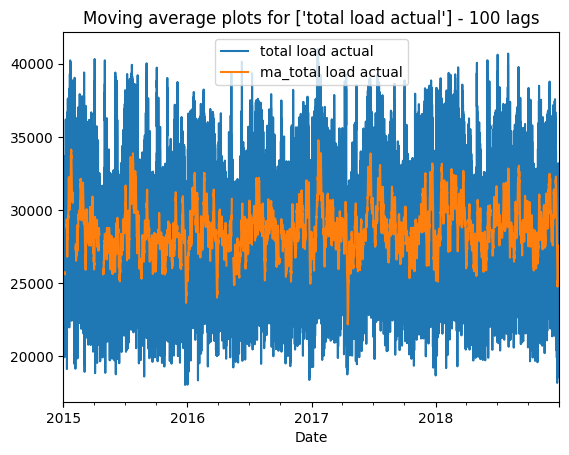

In [31]:
moving_average_plot(data, ["total load actual"], 100);

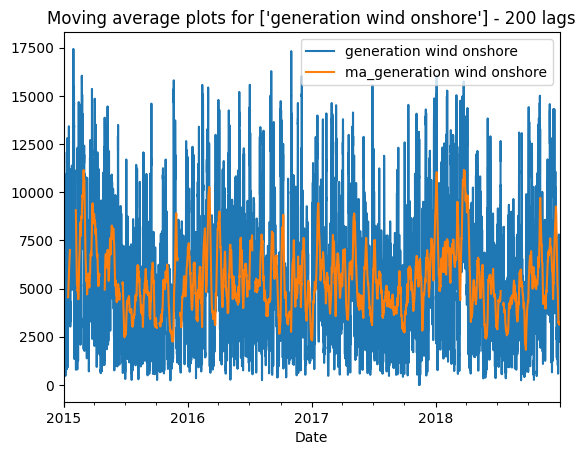

In [32]:
moving_average_plot(data, ["generation wind onshore"], 200);

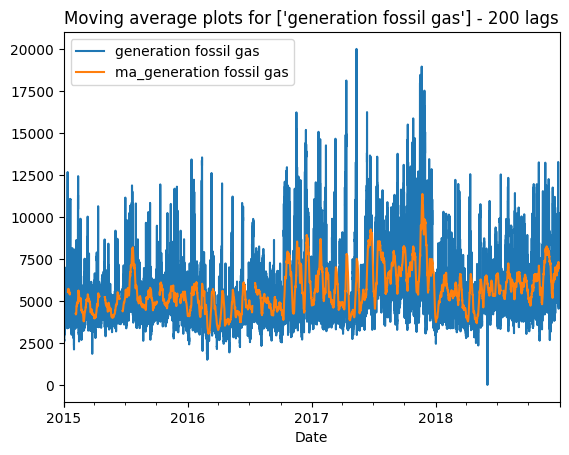

In [33]:
moving_average_plot(data, ["generation fossil gas"], 200);

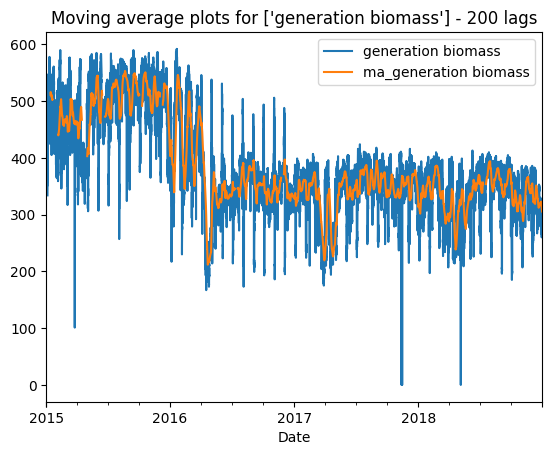

In [34]:
moving_average_plot(data, ["generation biomass"], 200);

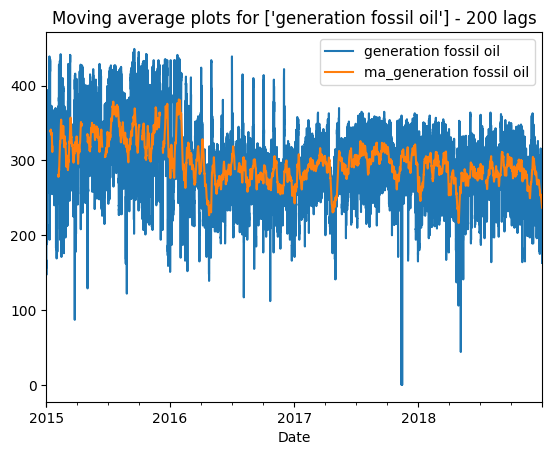

In [35]:
moving_average_plot(data, ["generation fossil oil"], 200);

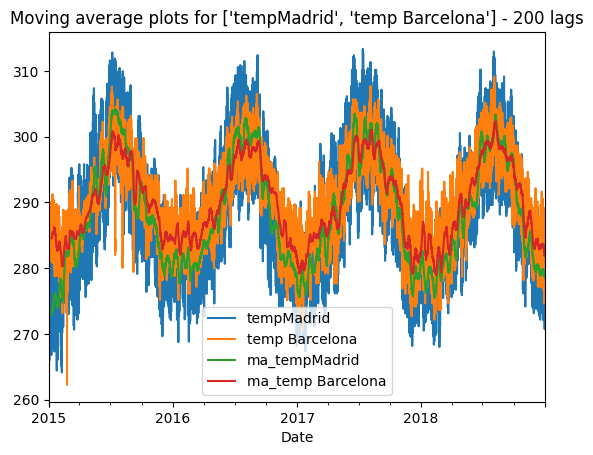

In [36]:
moving_average_plot(data, ["tempMadrid", "temp Barcelona"], 200);

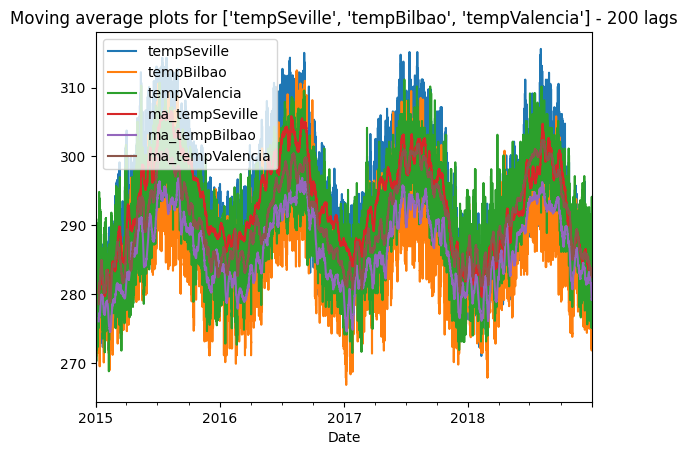

In [37]:
moving_average_plot(data, ["tempSeville", "tempBilbao", "tempValencia"], 200);

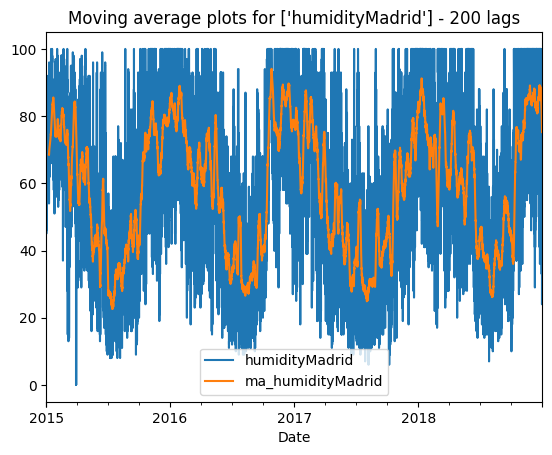

In [38]:
moving_average_plot(data, ["humidityMadrid"], 200);

In [39]:
data.columns[data.columns.str.contains("hum")]

Index(['humidityValencia', 'humidityMadrid', 'humidityBilbao',
       'humidity Barcelona', 'humiditySeville'],
      dtype='object')

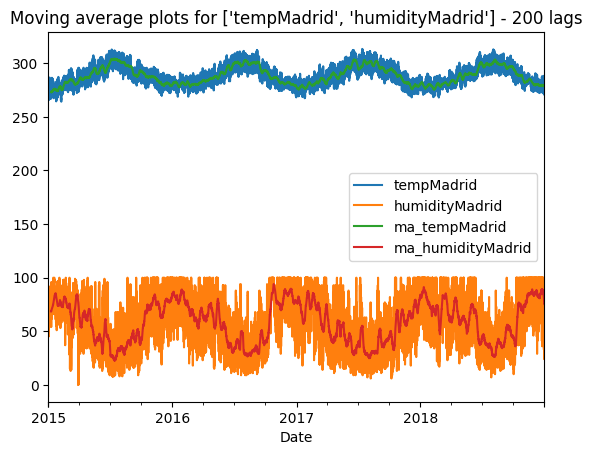

In [40]:
moving_average_plot(data, ["tempMadrid", "humidityMadrid"], 200);

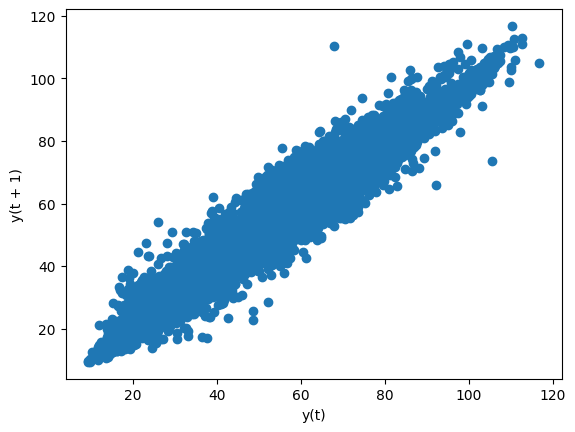

In [41]:
pd.plotting.lag_plot(data["price actual"], 1);

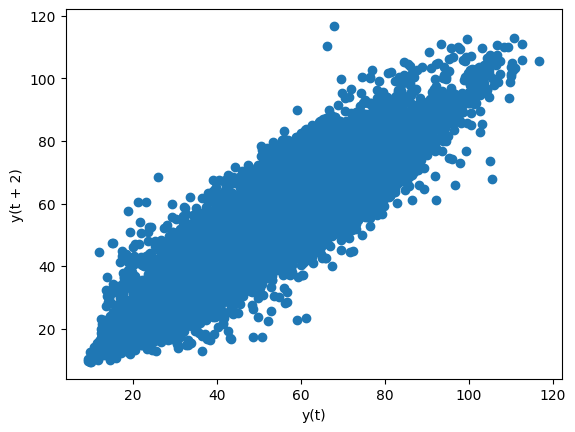

In [42]:
pd.plotting.lag_plot(data["price actual"], 2);

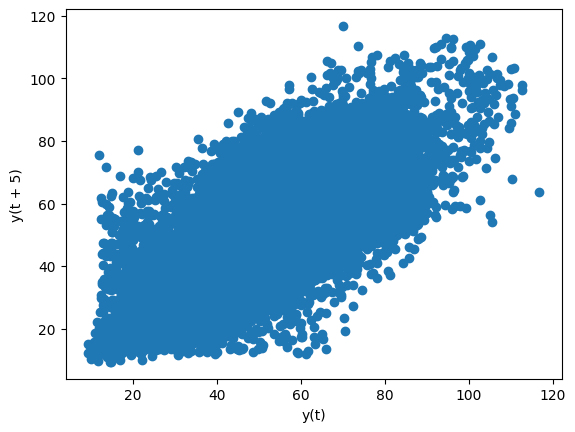

In [43]:
pd.plotting.lag_plot(data["price actual"], 5);

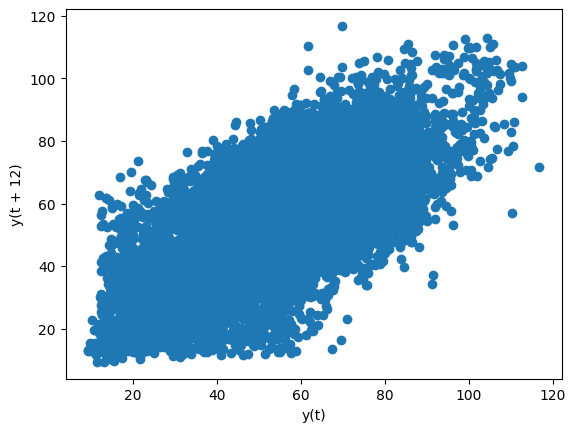

In [44]:
pd.plotting.lag_plot(data["price actual"], 12);

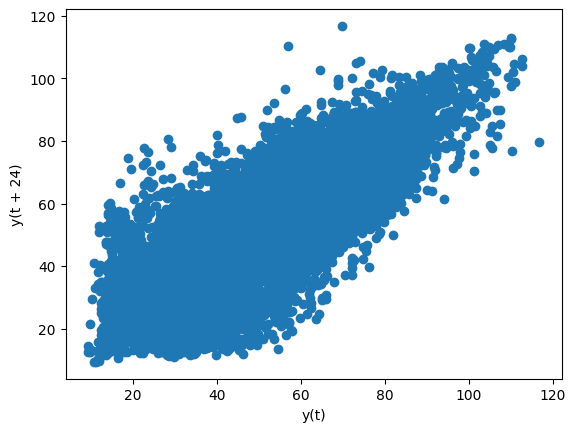

In [45]:
pd.plotting.lag_plot(data["price actual"], 24); # a day

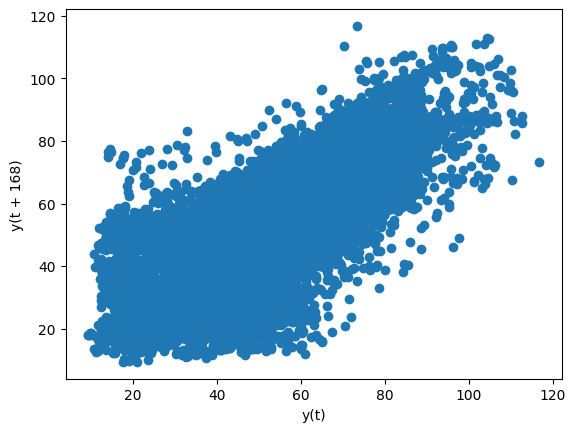

In [46]:
pd.plotting.lag_plot(data["price actual"], 24*7); # a week

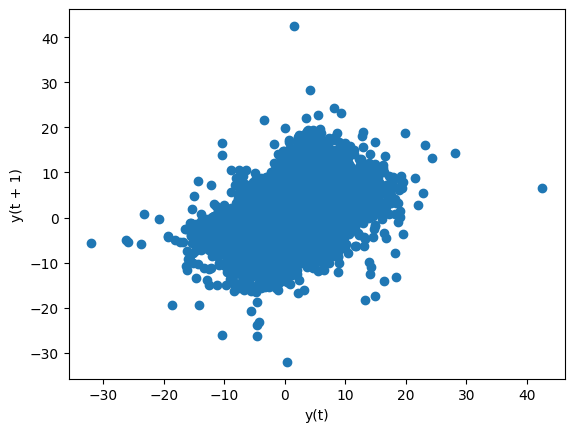

In [47]:
diff_lag_plot(data, "price actual", 1);

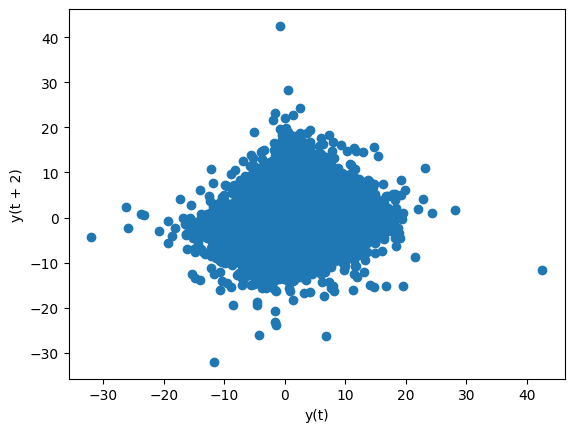

In [48]:
diff_lag_plot(data, "price actual", 2);

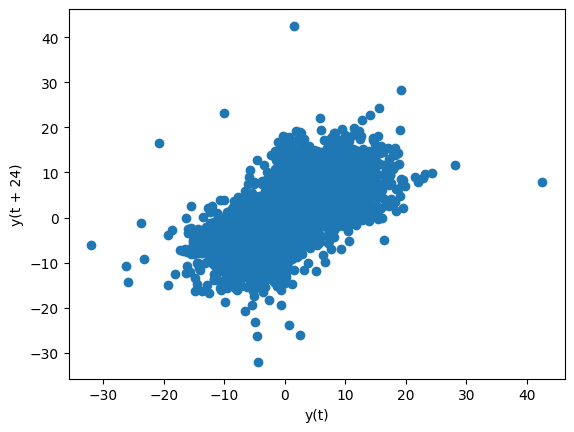

In [49]:
diff_lag_plot(data, "price actual", 24); # a day

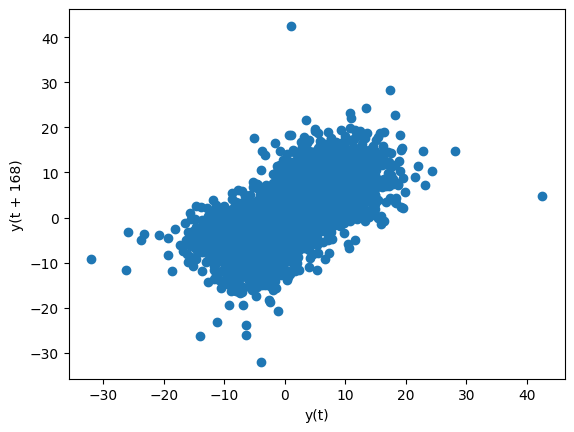

In [50]:
diff_lag_plot(data, "price actual", 24*7); # a week

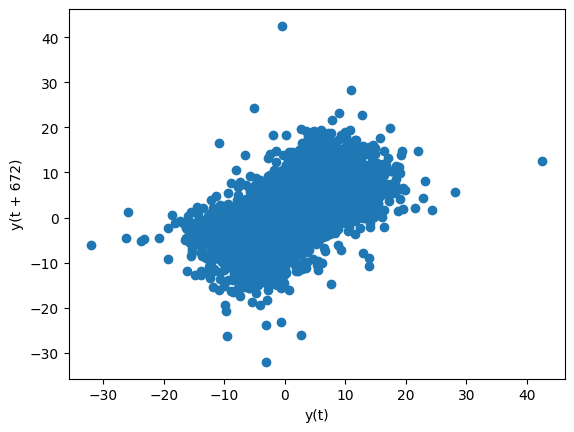

In [51]:
diff_lag_plot(data, "price actual", 24*7*4); # roughly a month

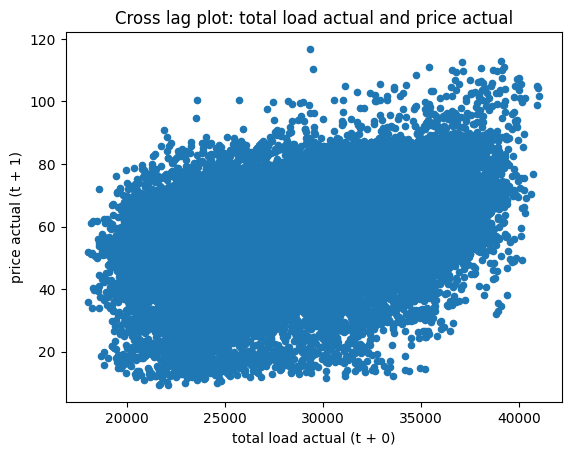

In [52]:
cross_lag_plot(data, "total load actual", "price actual", 0, 1);

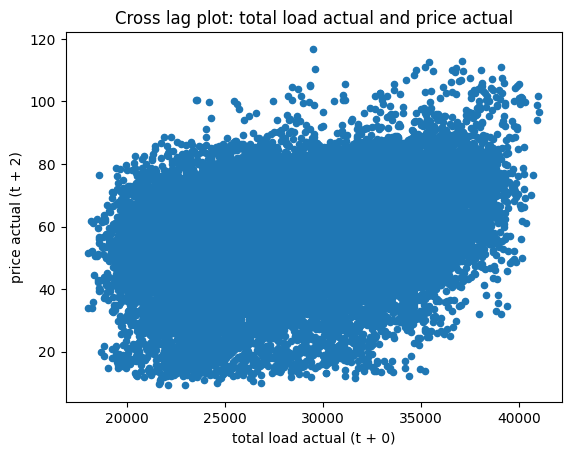

In [53]:
cross_lag_plot(data, "total load actual", "price actual", 0, 2);

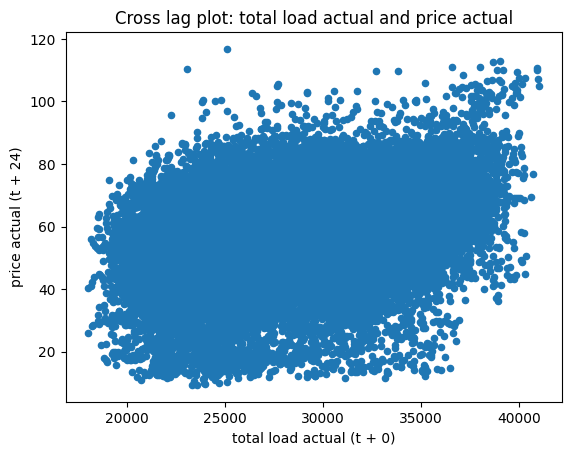

In [54]:
cross_lag_plot(data, "total load actual", "price actual", 0, 24);

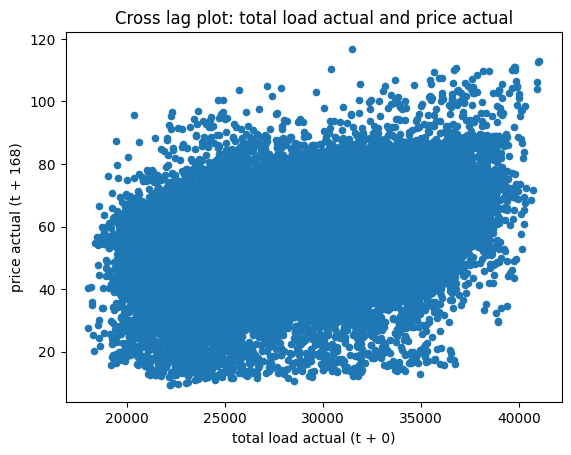

In [55]:
cross_lag_plot(data, "total load actual", "price actual", 0, 24*7);

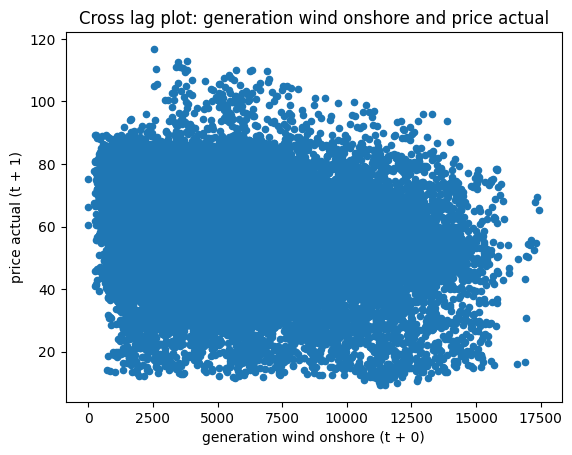

In [56]:
cross_lag_plot(data, "generation wind onshore", "price actual", 0, 1);

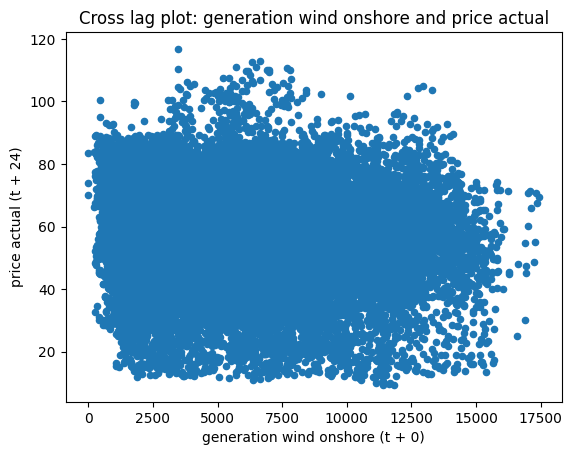

In [57]:
cross_lag_plot(data, "generation wind onshore", "price actual", 0, 24);

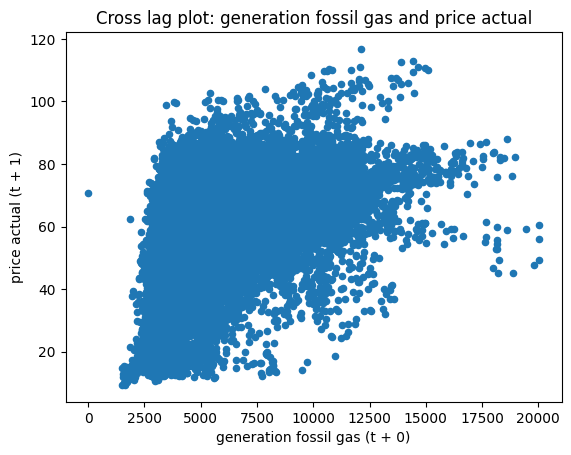

In [58]:
cross_lag_plot(data, "generation fossil gas", "price actual", 0, 1);

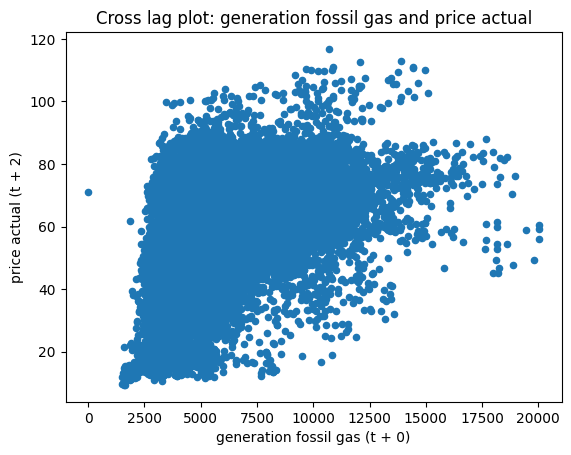

In [59]:
cross_lag_plot(data, "generation fossil gas", "price actual", 0, 2);

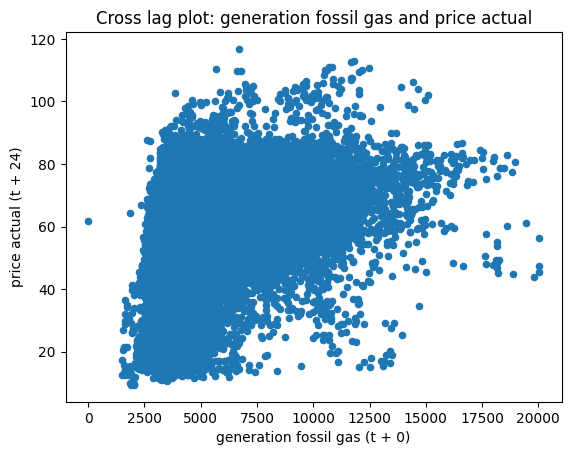

In [60]:
cross_lag_plot(data, "generation fossil gas", "price actual", 0, 24);

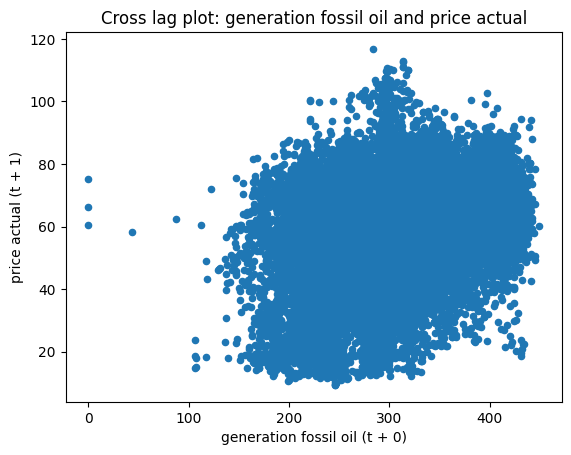

In [61]:
cross_lag_plot(data, "generation fossil oil", "price actual", 0, 1);

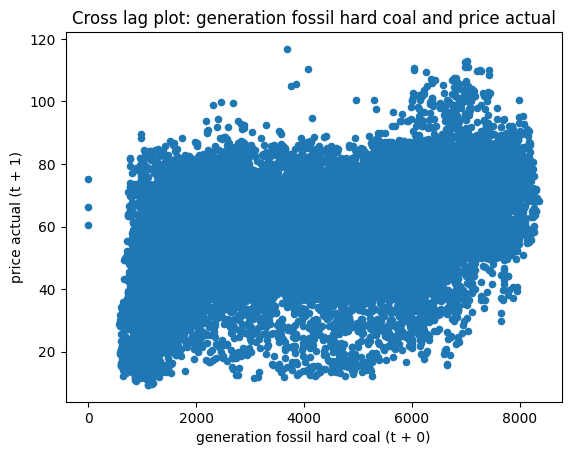

In [62]:
cross_lag_plot(data, "generation fossil hard coal", "price actual", 0, 1);

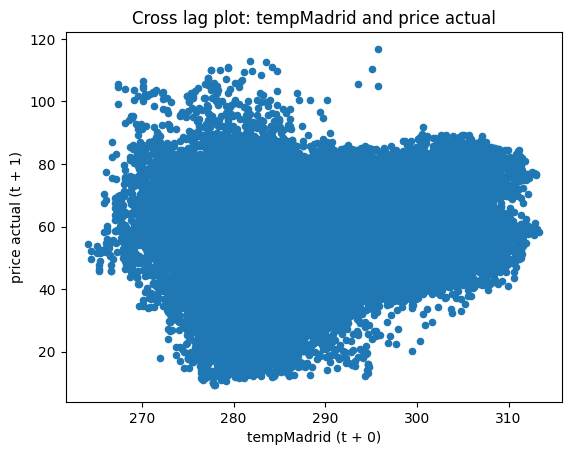

In [63]:
cross_lag_plot(data, "tempMadrid", "price actual", 0, 1);

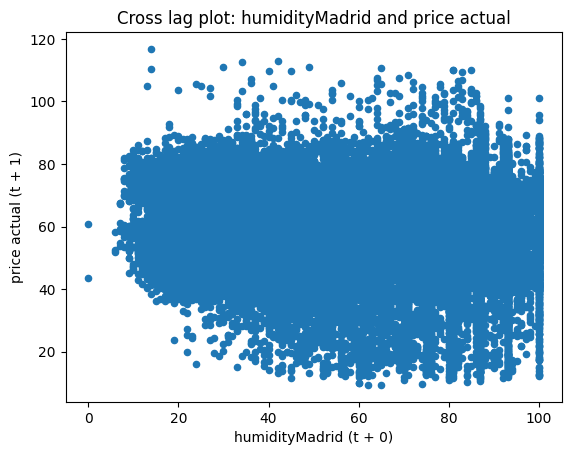

In [64]:
cross_lag_plot(data, "humidityMadrid", "price actual", 0, 1);

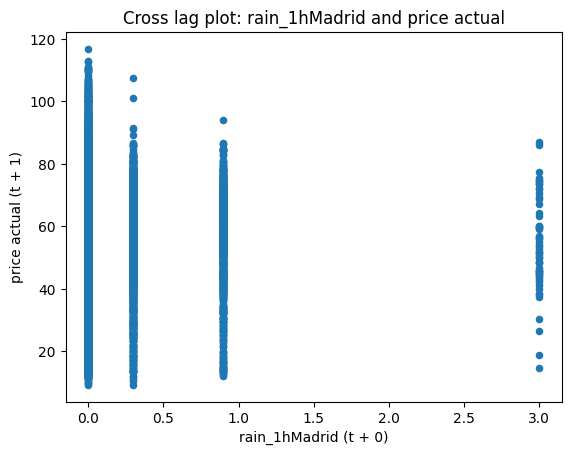

In [65]:
cross_lag_plot(data, "rain_1hMadrid", "price actual", 0, 1);

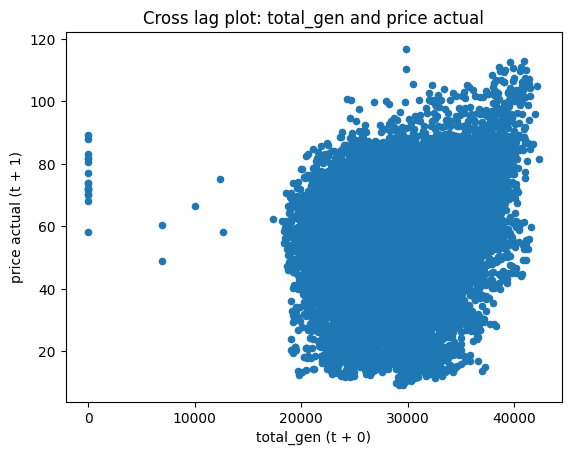

In [66]:
cross_lag_plot(data, "total_gen", "price actual", 0, 1);

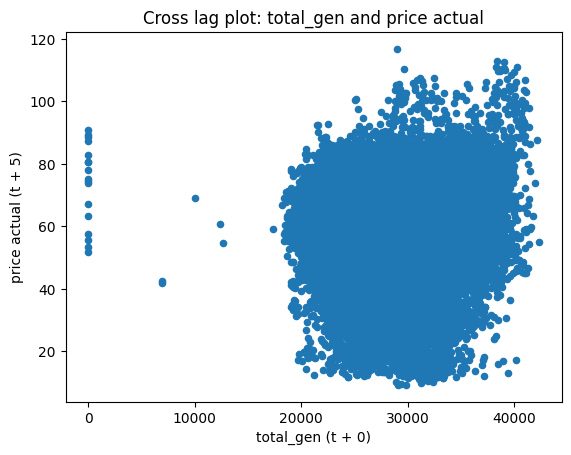

In [67]:
cross_lag_plot(data, "total_gen", "price actual", 0, 5);

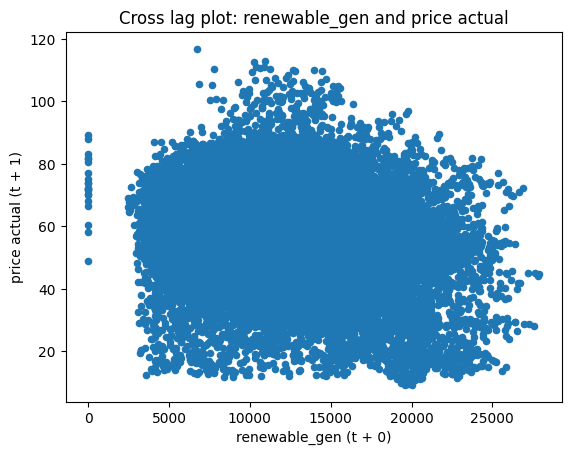

In [68]:
cross_lag_plot(data, "renewable_gen", "price actual", 0, 1);

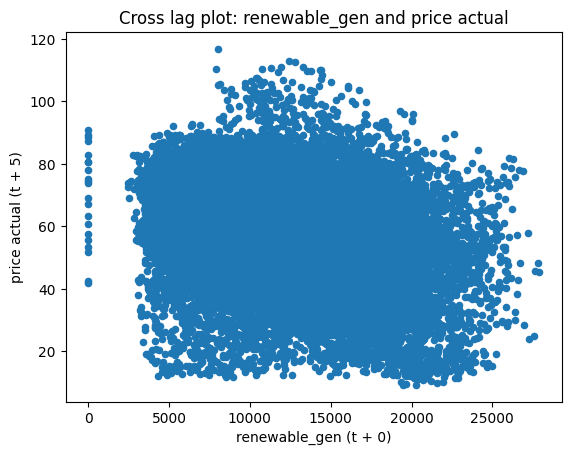

In [69]:
cross_lag_plot(data, "renewable_gen", "price actual", 0, 5);

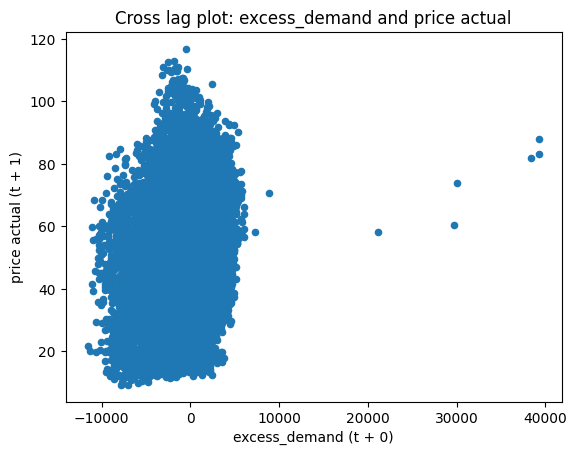

In [70]:
cross_lag_plot(data, "excess_demand", "price actual", 0, 1);

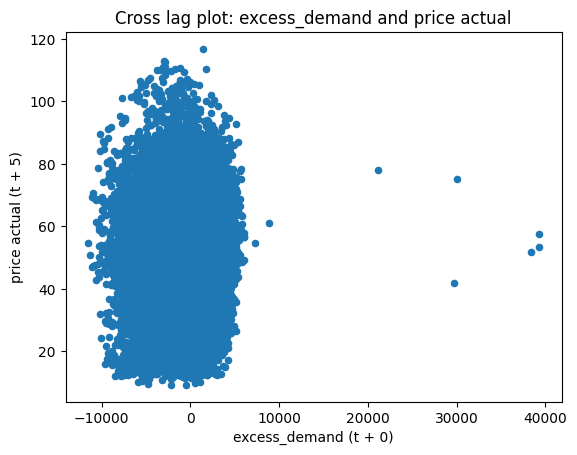

In [71]:
cross_lag_plot(data, "excess_demand", "price actual", 0, 5);

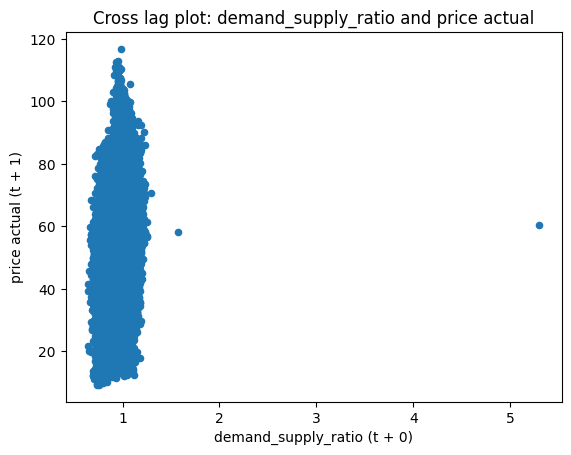

In [72]:
cross_lag_plot(data, "demand_supply_ratio", "price actual", 0, 1);

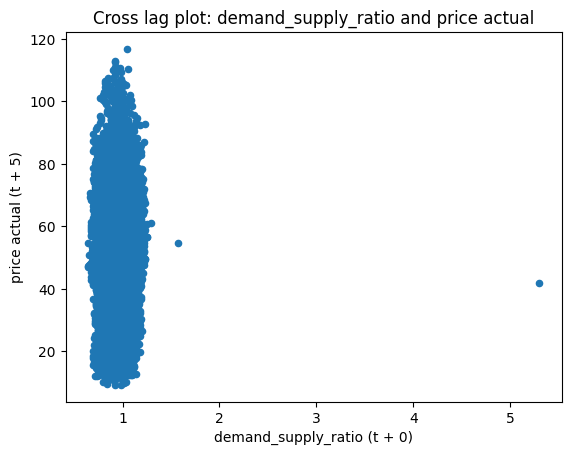

In [73]:
cross_lag_plot(data, "demand_supply_ratio", "price actual", 0, 5);

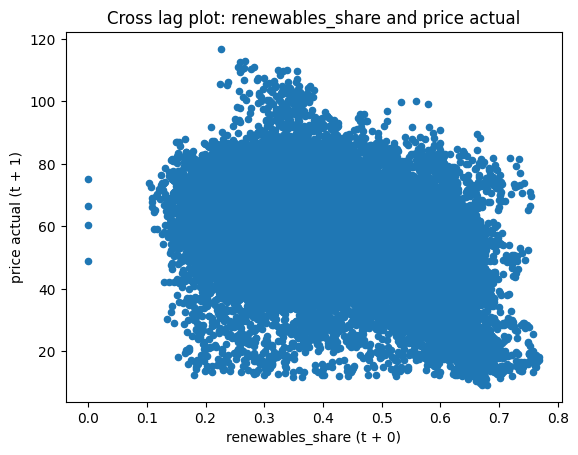

In [74]:
cross_lag_plot(data, "renewables_share", "price actual", 0, 1);

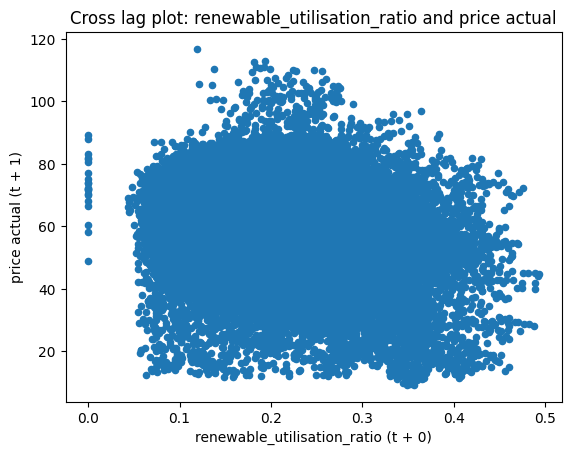

In [75]:
cross_lag_plot(data, "renewable_utilisation_ratio", "price actual", 0, 1);

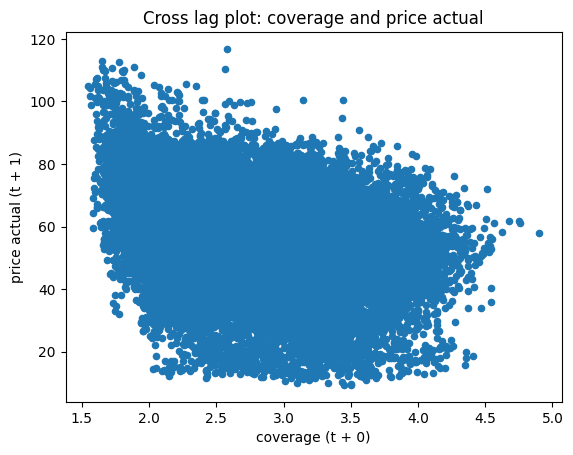

In [76]:
cross_lag_plot(data, "coverage", "price actual", 0, 1);

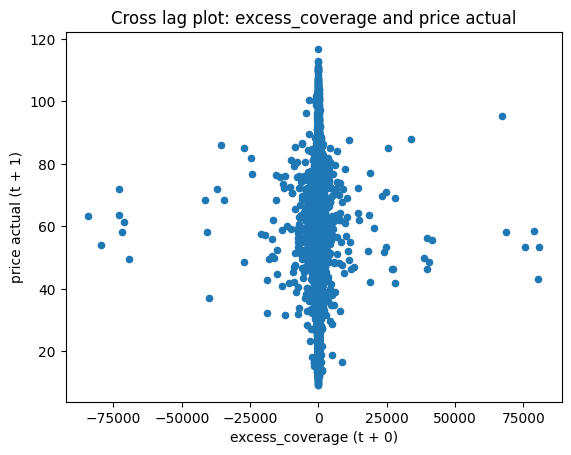

In [77]:
cross_lag_plot(data, "excess_coverage", "price actual", 0, 1);

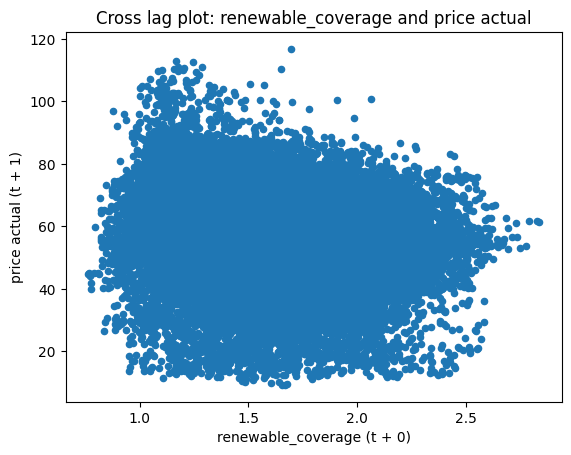

In [78]:
cross_lag_plot(data, "renewable_coverage", "price actual", 0, 1);

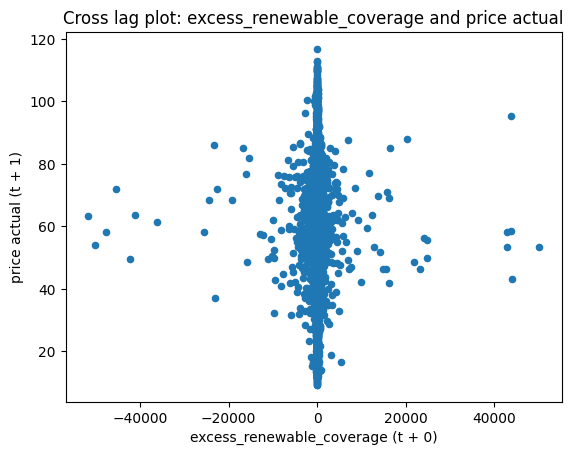

In [79]:
cross_lag_plot(data, "excess_renewable_coverage", "price actual", 0, 1);

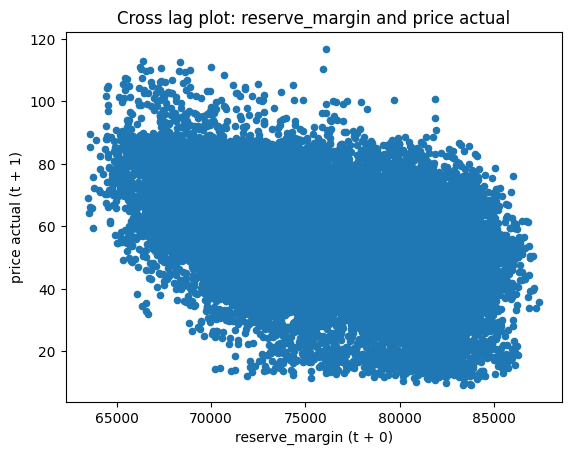

In [80]:
cross_lag_plot(data, "reserve_margin", "price actual", 0, 1);

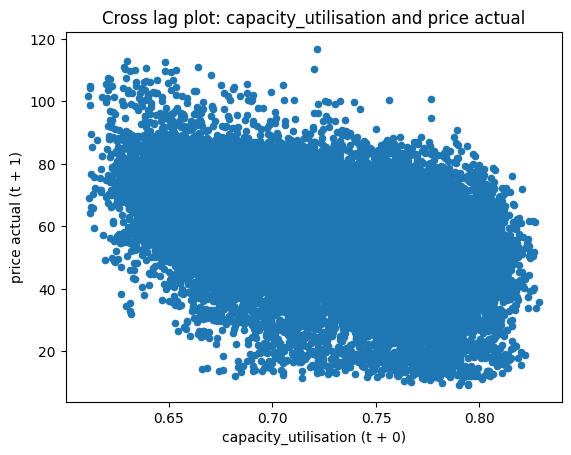

In [81]:
cross_lag_plot(data, "capacity_utilisation", "price actual", 0, 1);

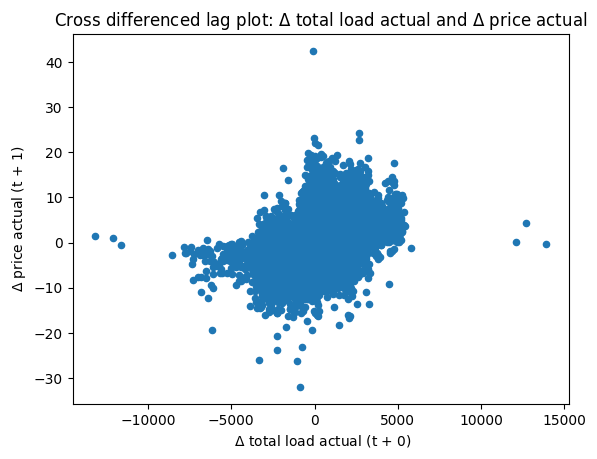

In [82]:
cross_diff_lag_plot(data, "total load actual", "price actual", 0, 1);

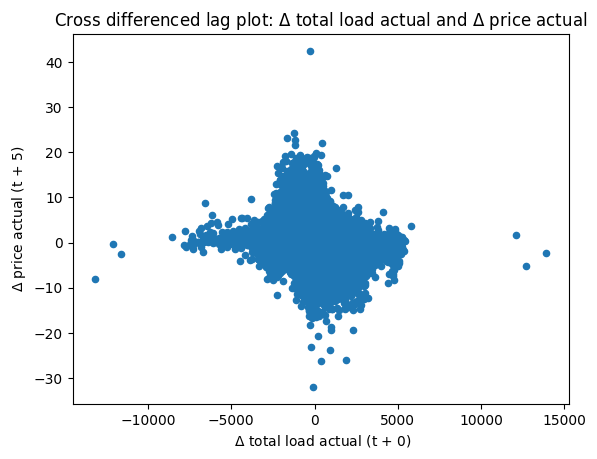

In [83]:
cross_diff_lag_plot(data, "total load actual", "price actual", 0, 5);

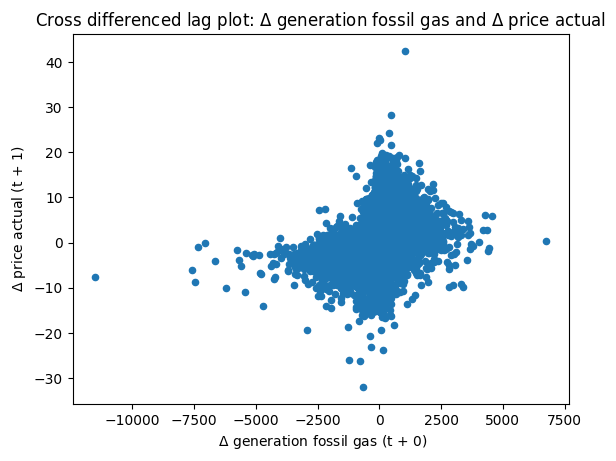

In [84]:
cross_diff_lag_plot(data, "generation fossil gas", "price actual", 0, 1);

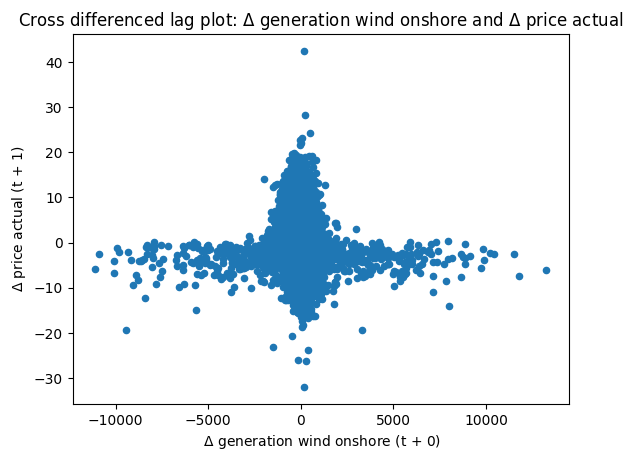

In [85]:
cross_diff_lag_plot(data, "generation wind onshore", "price actual", 0, 1);

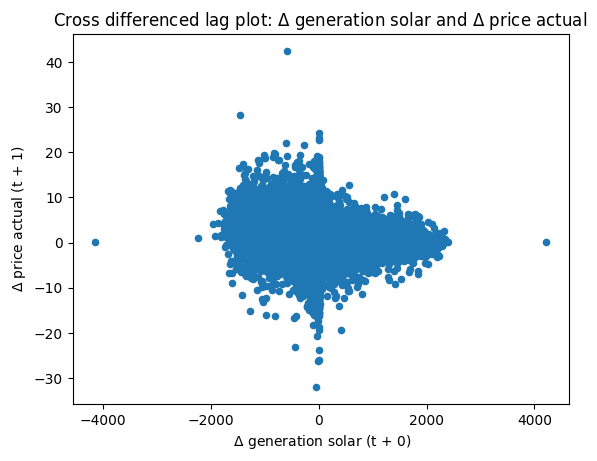

In [86]:
cross_diff_lag_plot(data, "generation solar", "price actual", 0, 1);

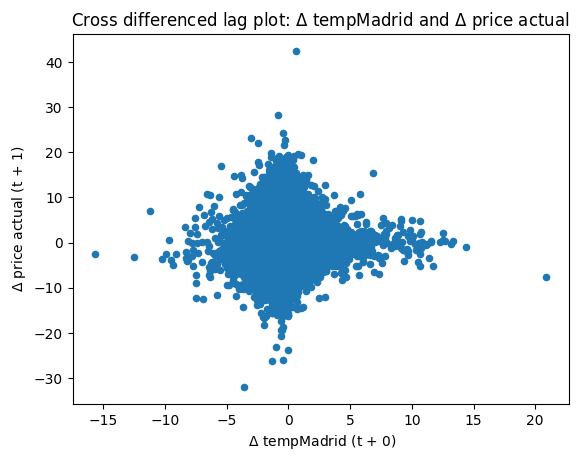

In [87]:
cross_diff_lag_plot(data, "tempMadrid", "price actual", 0, 1);

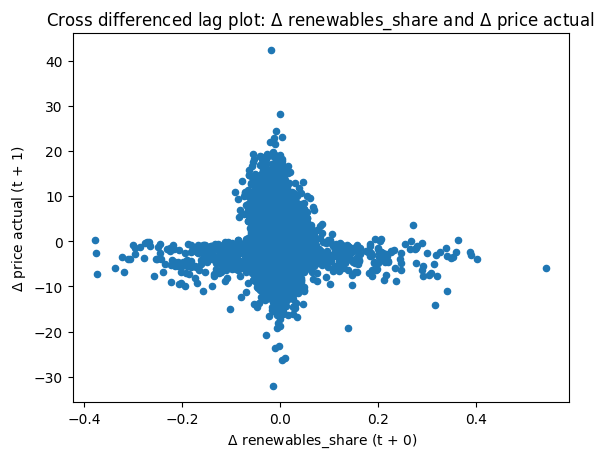

In [88]:
cross_diff_lag_plot(data, "renewables_share", "price actual", 0, 1);

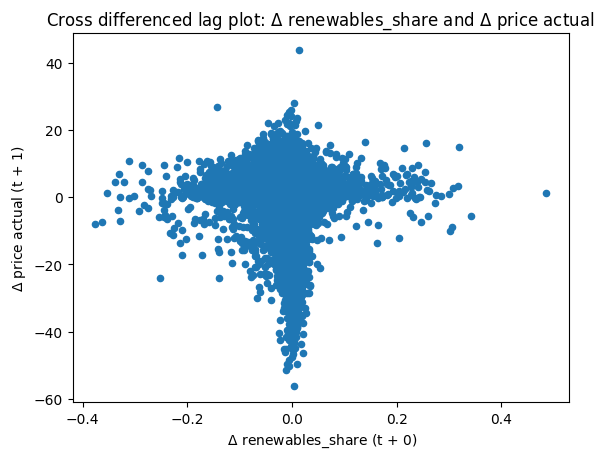

In [89]:
cross_diff_lag_plot(data.loc[data["total load actual"].diff() > 0], "renewables_share", "price actual", 0, 1);

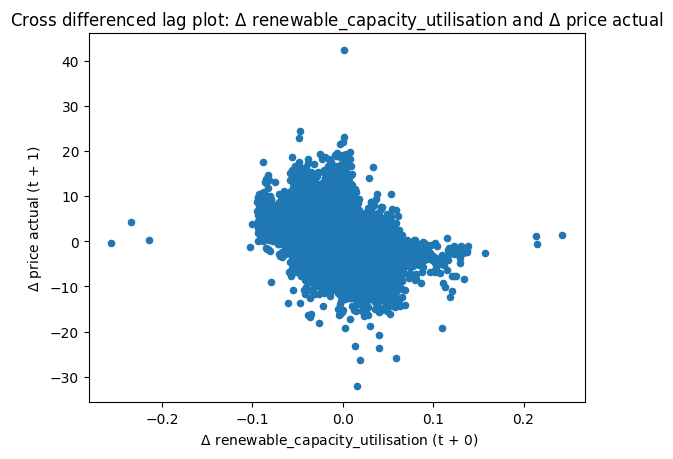

In [90]:
cross_diff_lag_plot(data, "renewable_capacity_utilisation", "price actual", 0, 1);

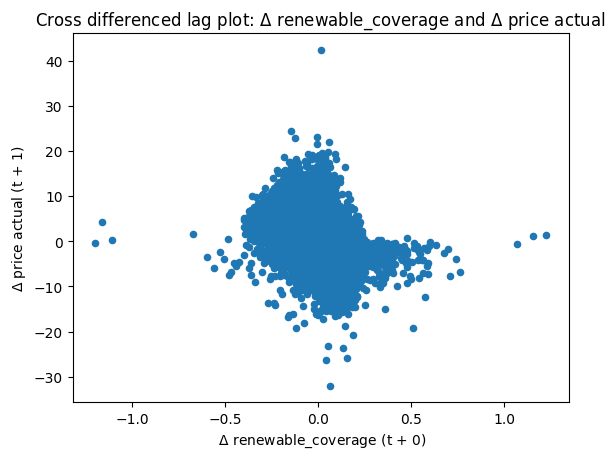

In [91]:
cross_diff_lag_plot(data, "renewable_coverage", "price actual", 0, 1);

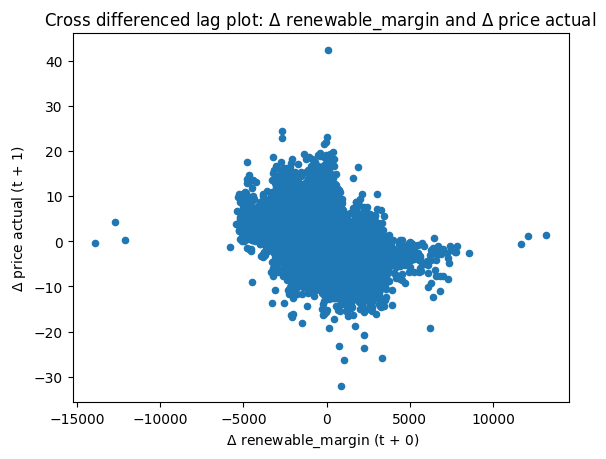

In [92]:
cross_diff_lag_plot(data, "renewable_margin", "price actual", 0, 1);

#### Monthly averages

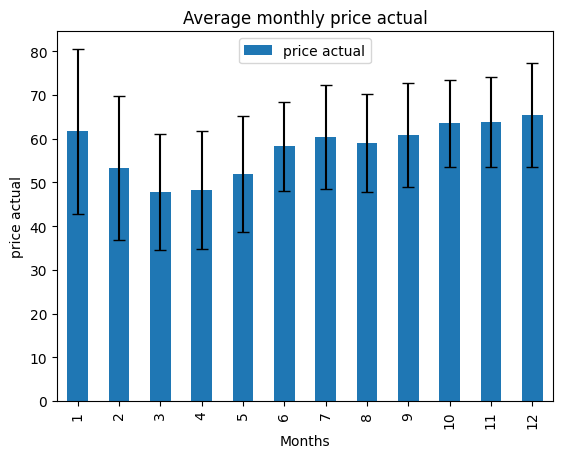

In [93]:
monthly_averages(data, "price actual");

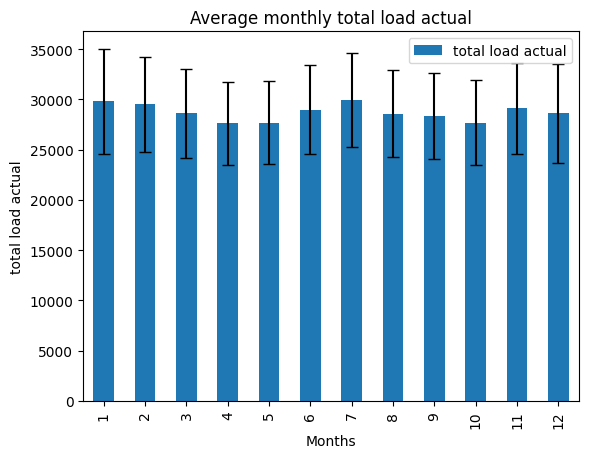

In [94]:
monthly_averages(data, "total load actual");

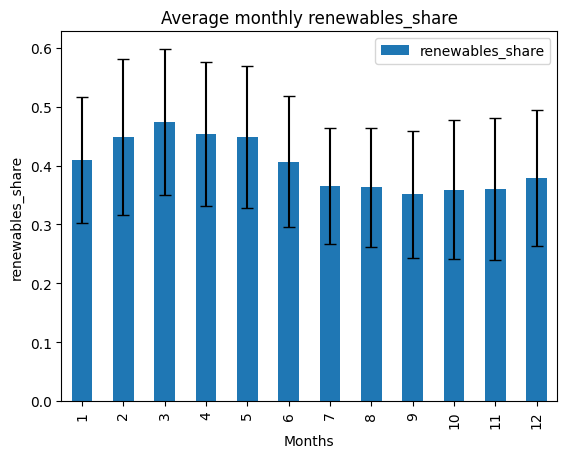

In [95]:
monthly_averages(data, "renewables_share");

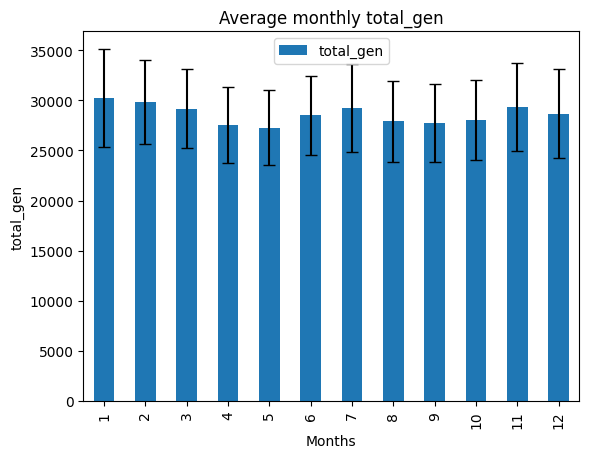

In [96]:
monthly_averages(data, "total_gen");

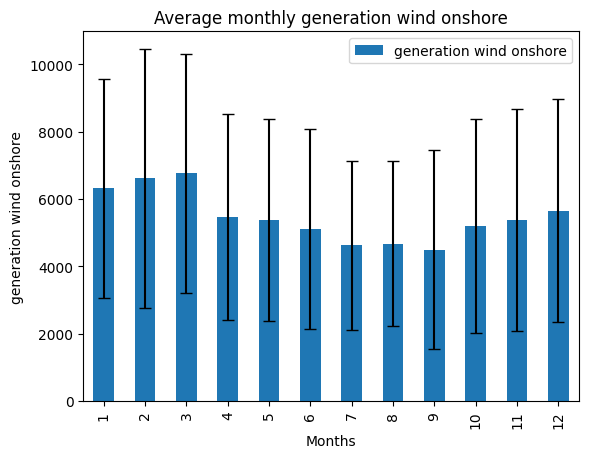

In [97]:
monthly_averages(data, "generation wind onshore");

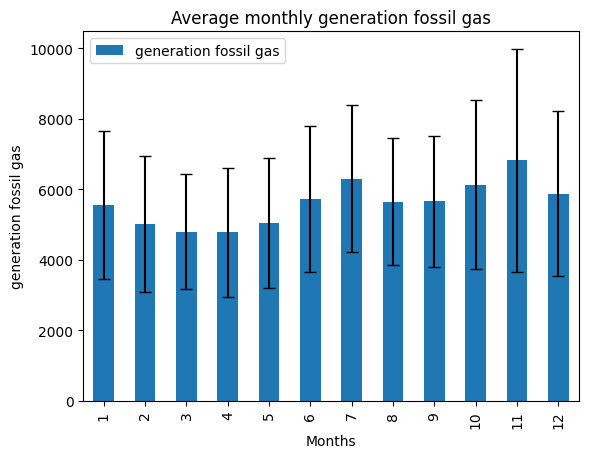

In [98]:
monthly_averages(data, "generation fossil gas");

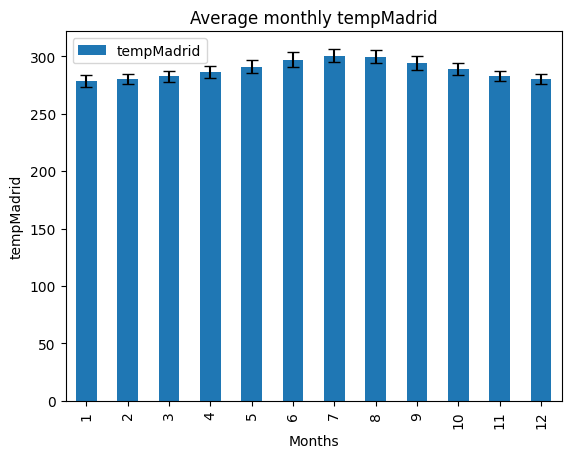

In [99]:
monthly_averages(data, "tempMadrid");

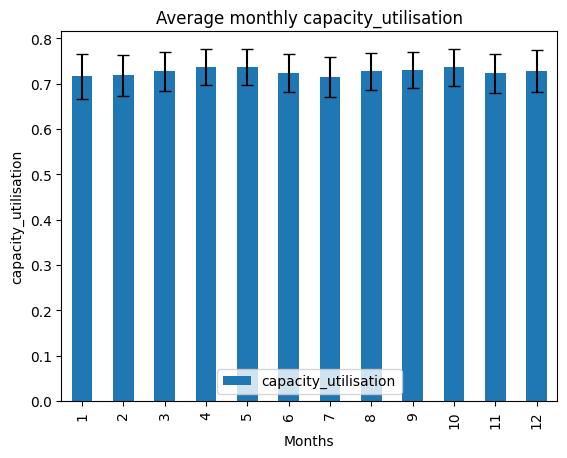

In [100]:
monthly_averages(data, "capacity_utilisation");

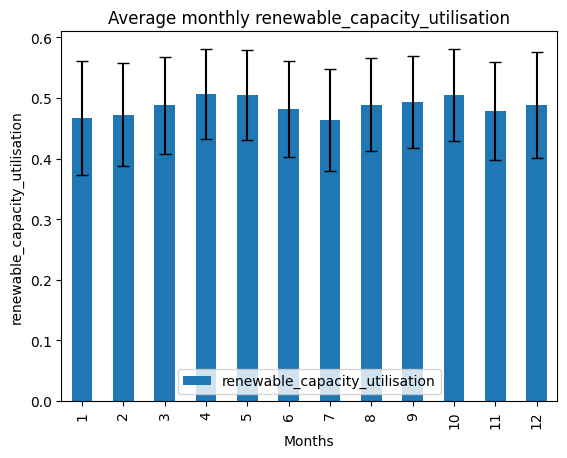

In [101]:
monthly_averages(data, "renewable_capacity_utilisation");

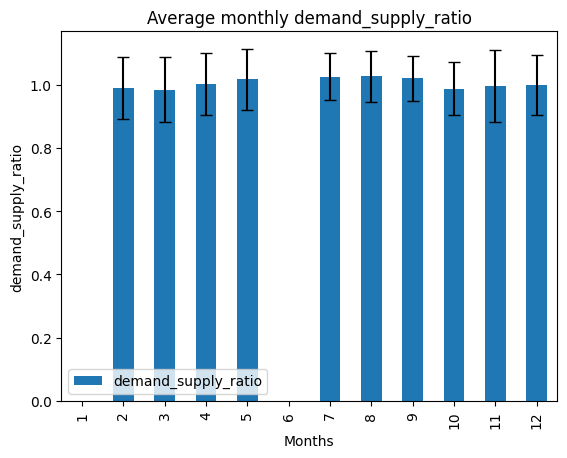

In [102]:
monthly_averages(data, "demand_supply_ratio");

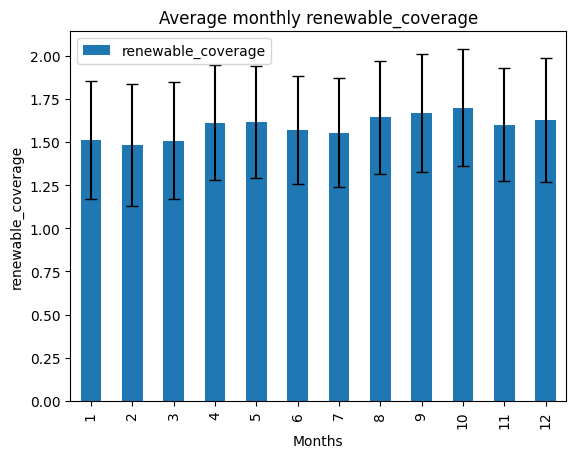

In [103]:
monthly_averages(data, "renewable_coverage");

#### Weekday averages

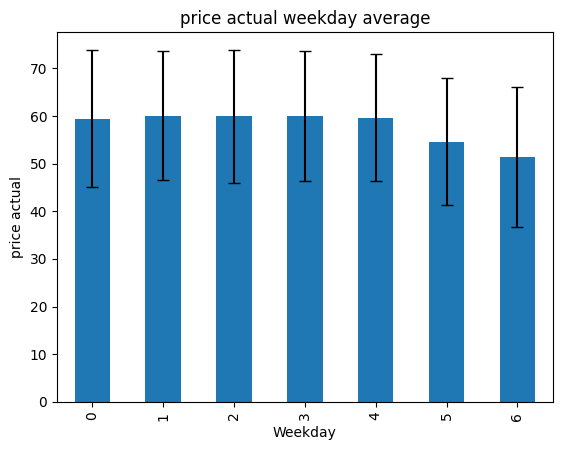

In [104]:
weekday_averages(data, "price actual");

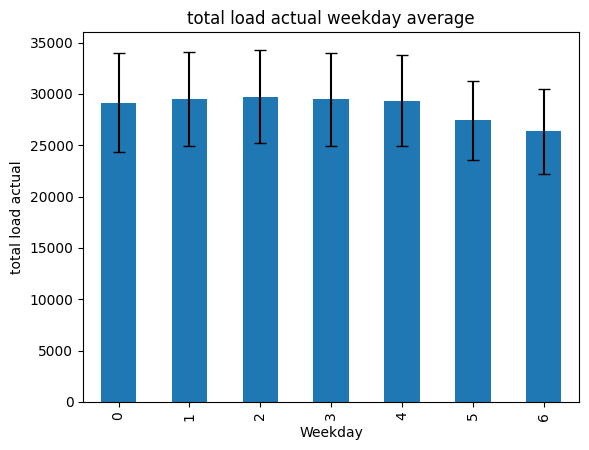

In [105]:
weekday_averages(data, "total load actual");

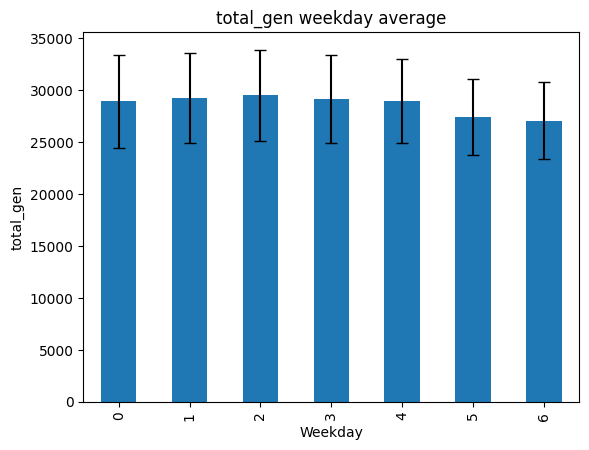

In [106]:
weekday_averages(data, "total_gen");

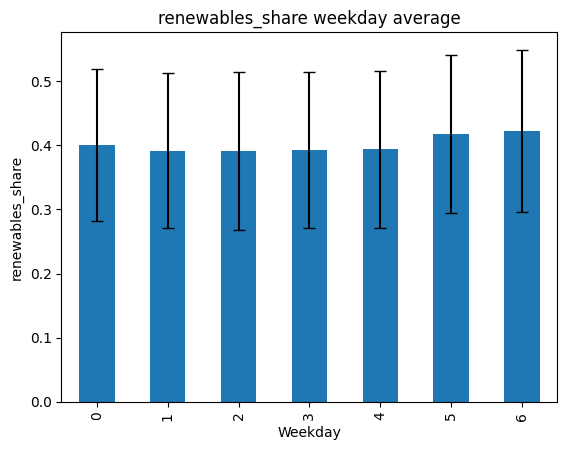

In [107]:
weekday_averages(data, "renewables_share");

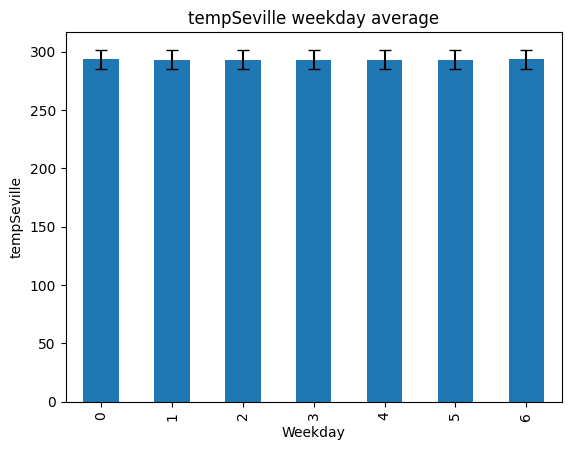

In [108]:
weekday_averages(data, "tempSeville");

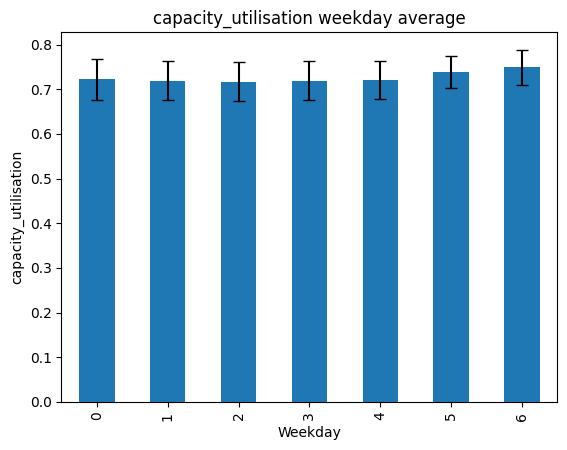

In [109]:
weekday_averages(data, "capacity_utilisation");

#### Hourly averages

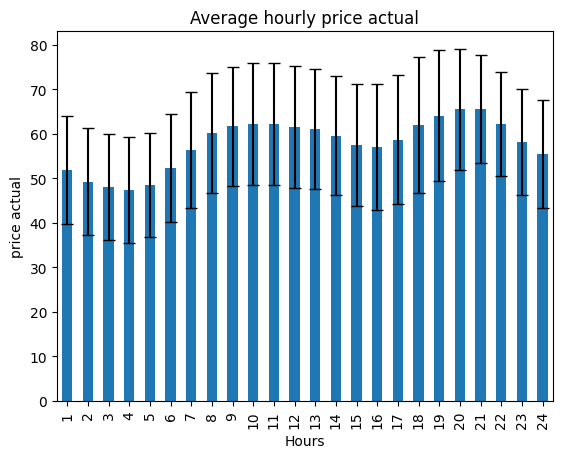

In [110]:
hourly_averages(data, "price actual");

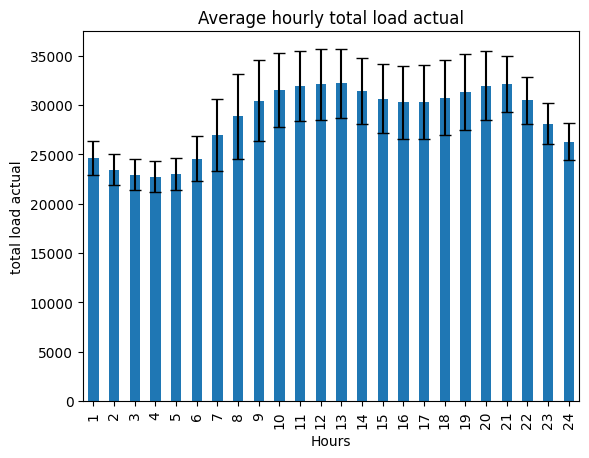

In [111]:
hourly_averages(data, "total load actual");

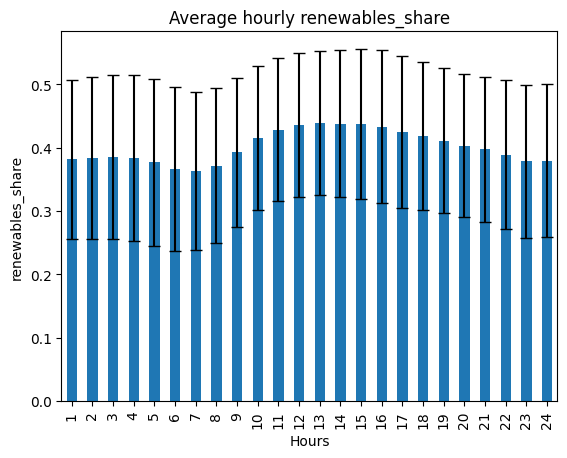

In [112]:
hourly_averages(data, "renewables_share");

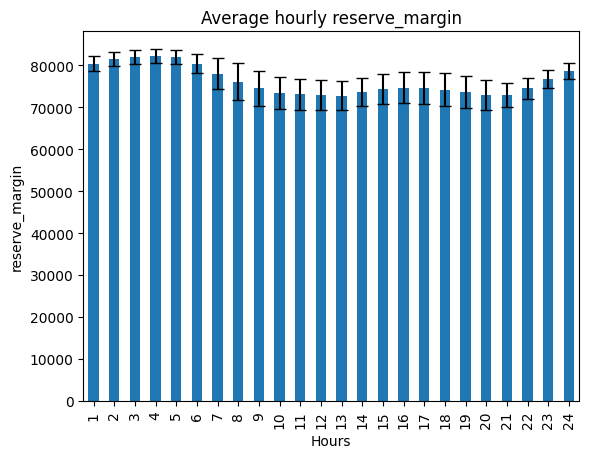

In [113]:
hourly_averages(data, "reserve_margin");

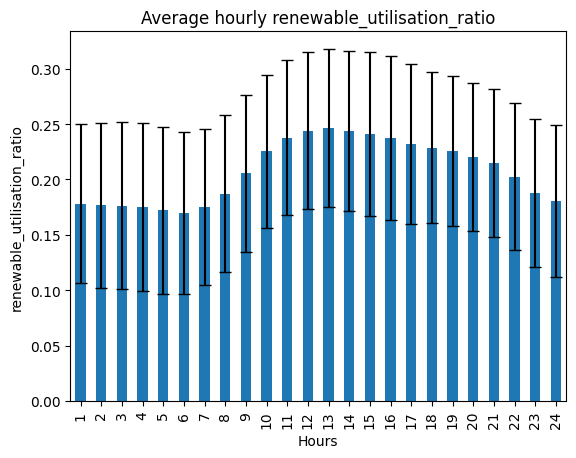

In [114]:
hourly_averages(data, "renewable_utilisation_ratio");

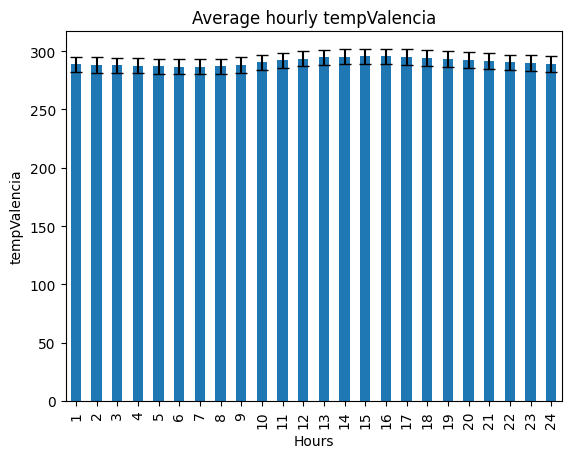

In [115]:
hourly_averages(data, "tempValencia");

#### 2-factor plots

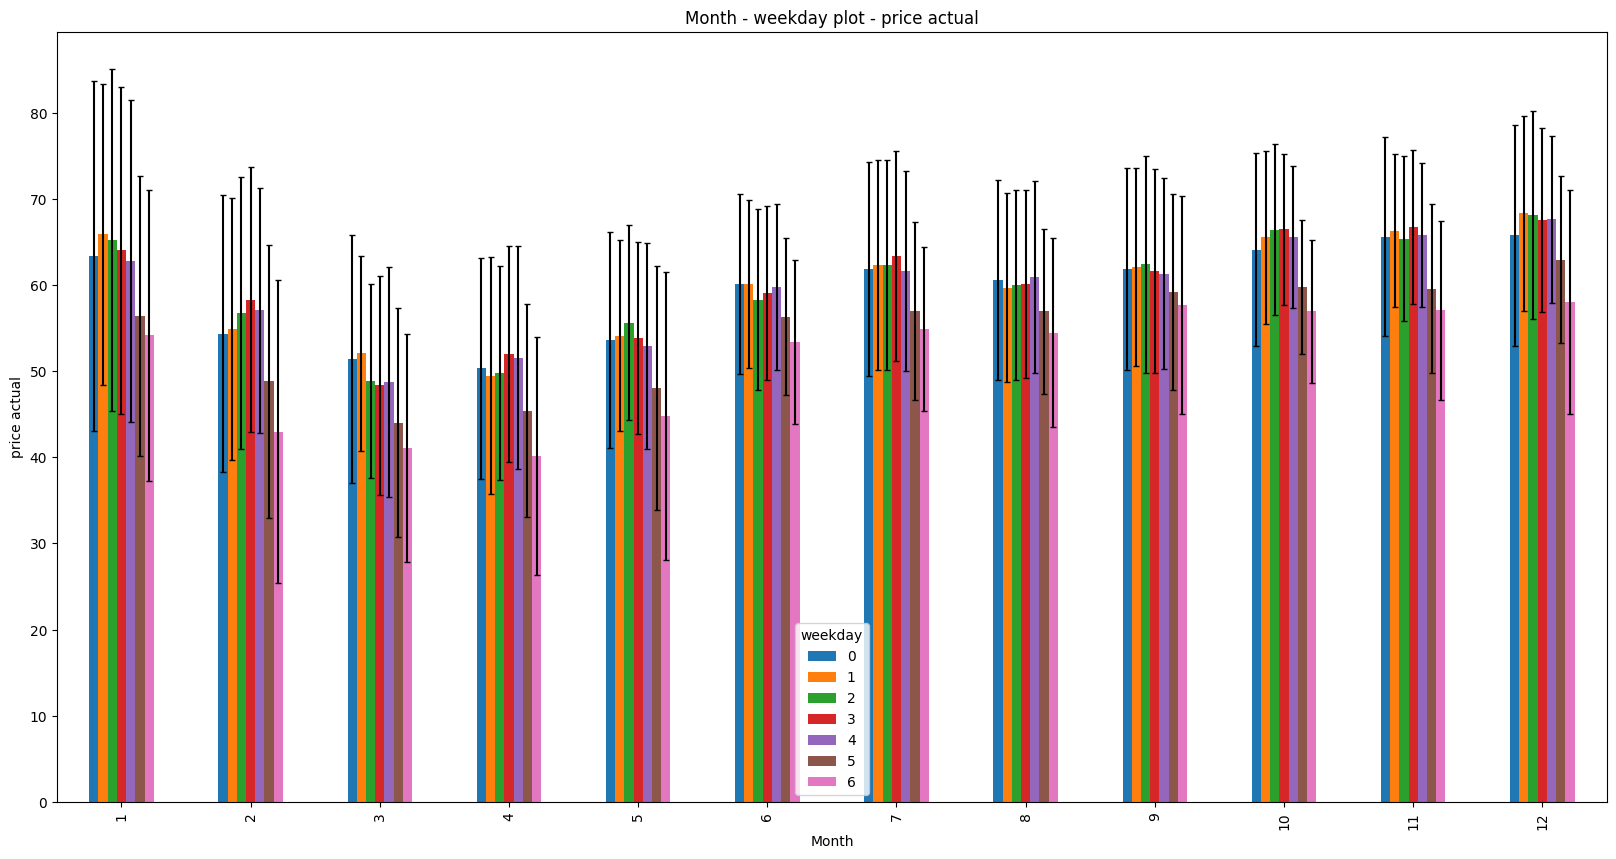

In [116]:
weekday_per_month(data, "price actual");

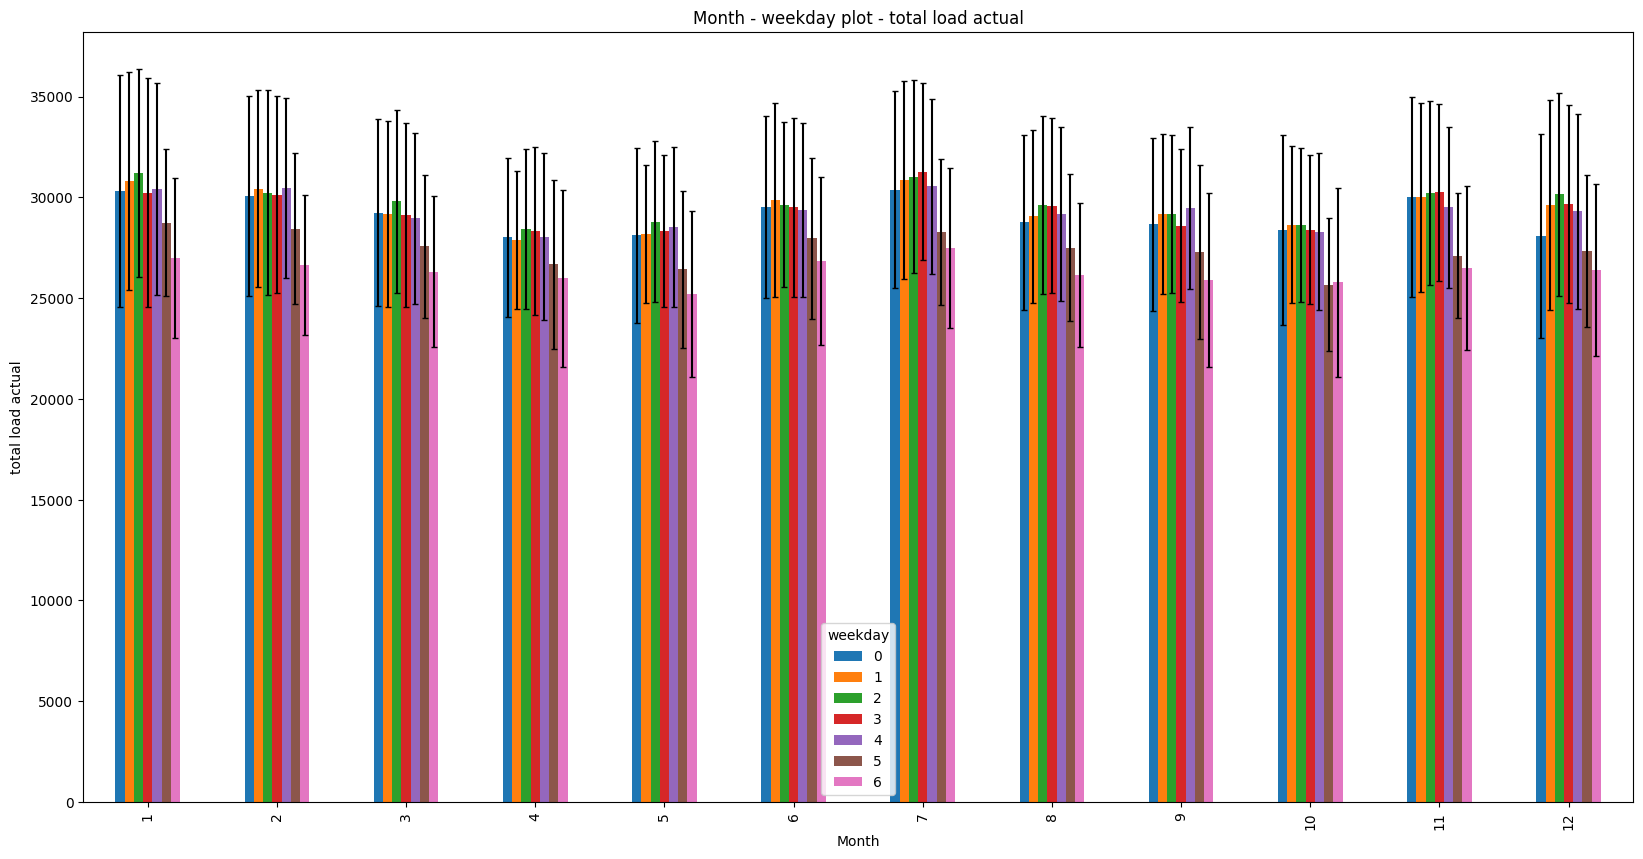

In [117]:
weekday_per_month(data, "total load actual");

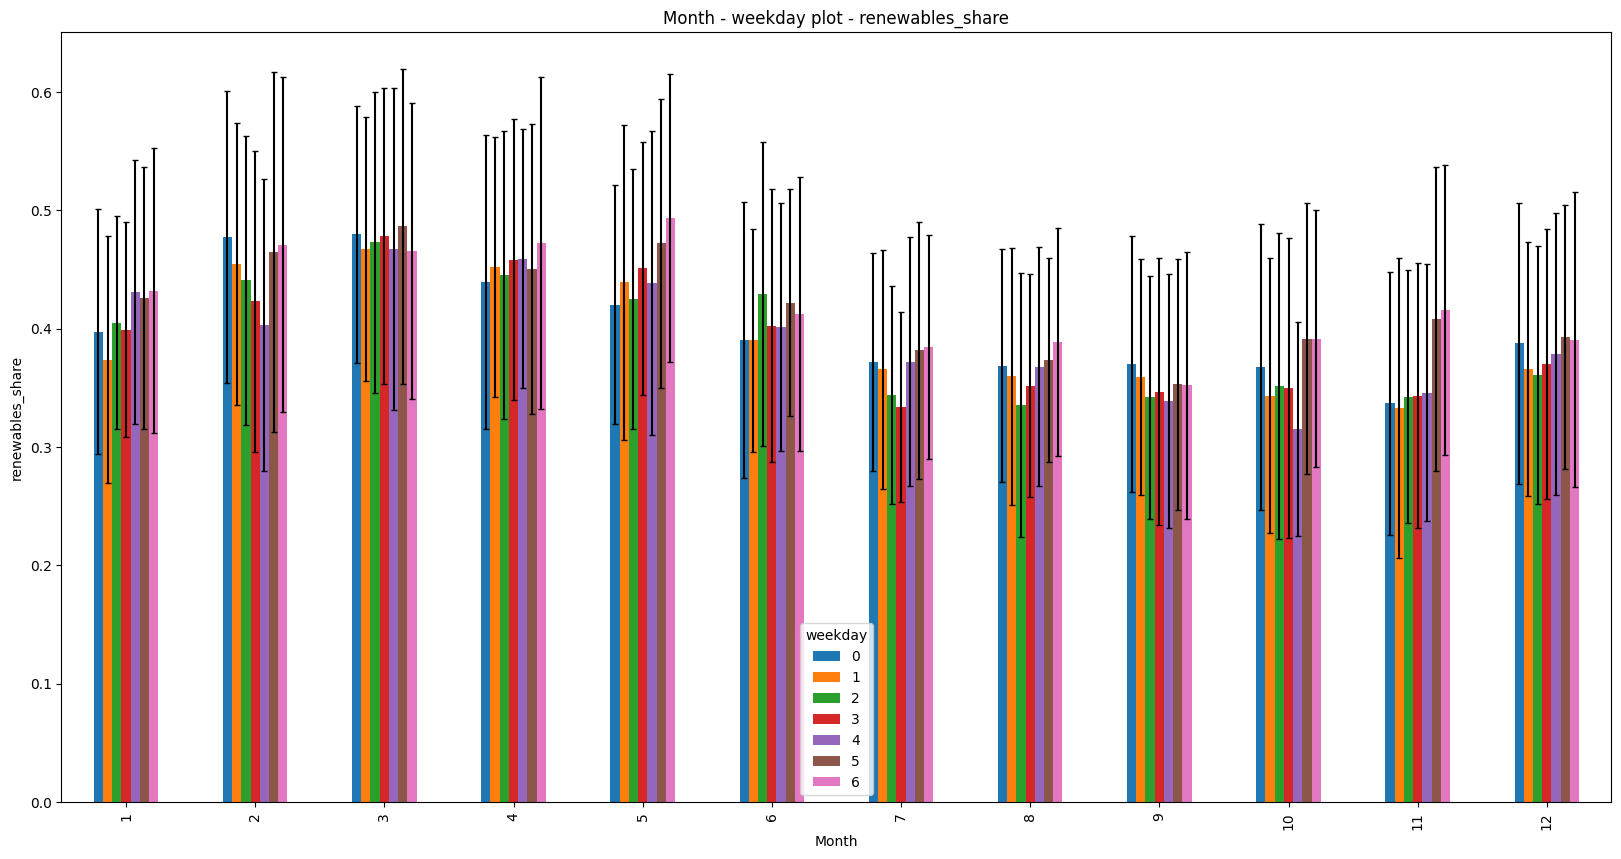

In [118]:
weekday_per_month(data, "renewables_share");

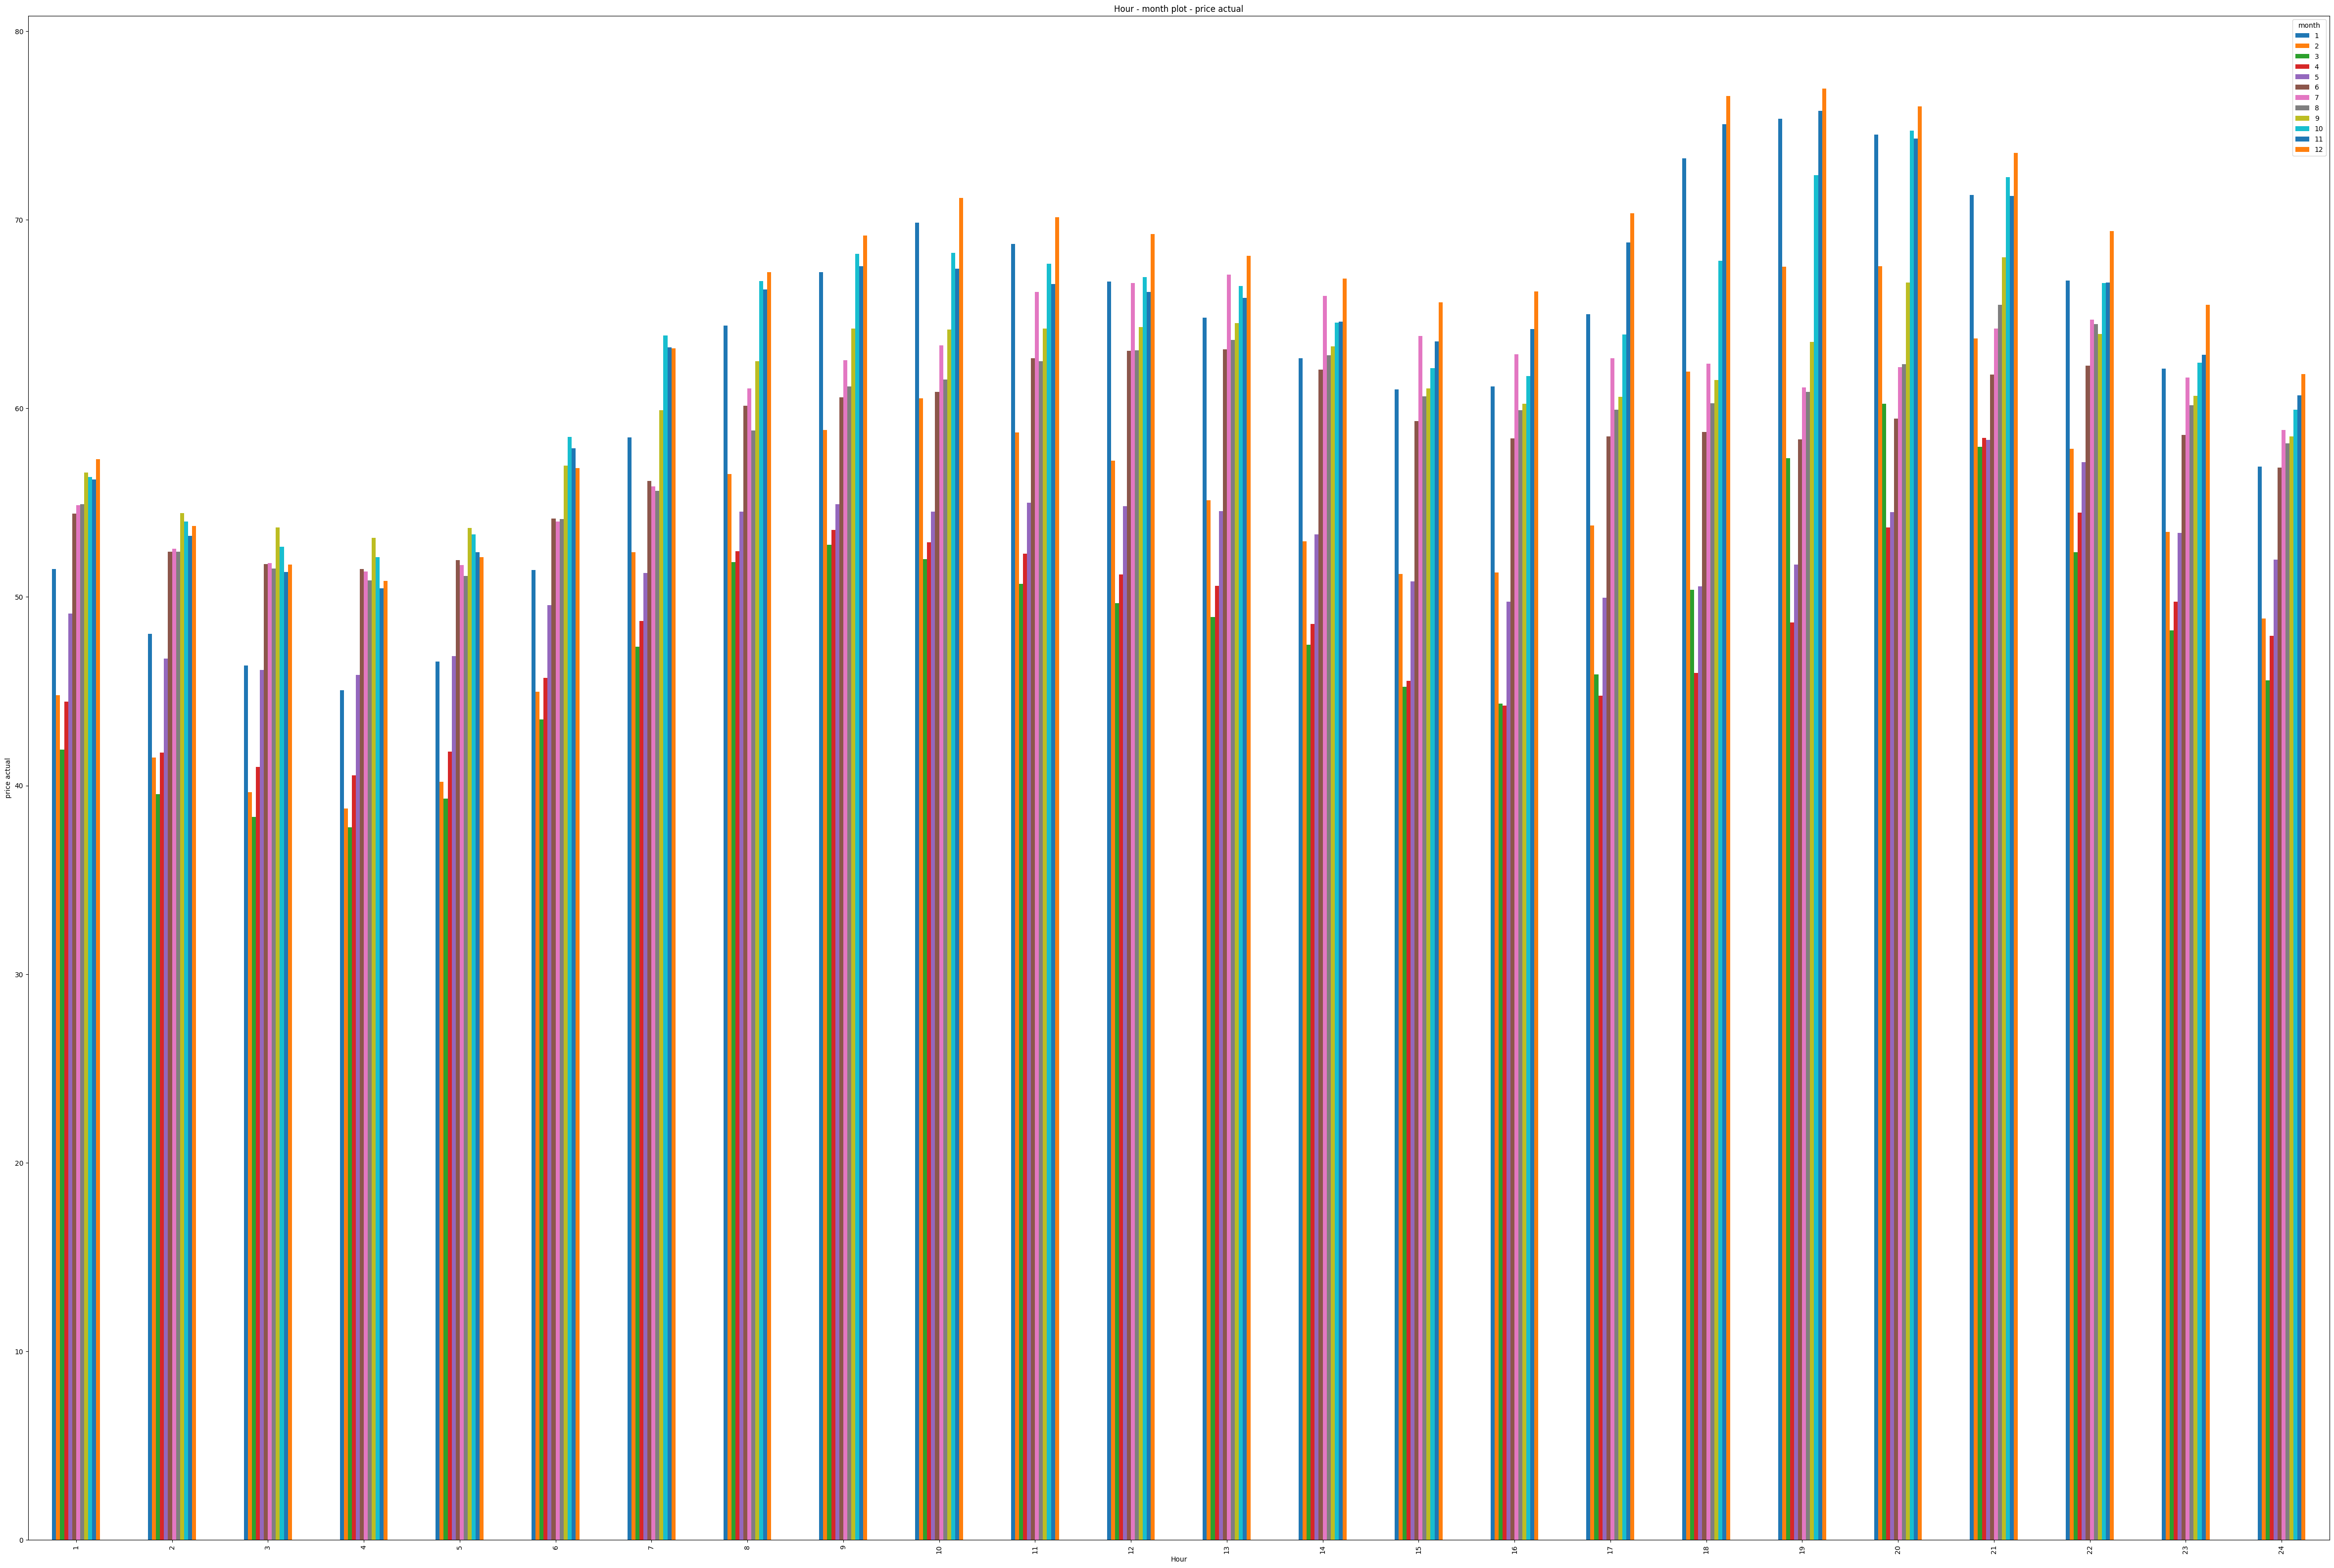

In [119]:
hourly_per_month(data, "price actual");

In [120]:
selected_data = data[["price actual", "total load actual", "renewables_share"]].copy();
selected_data["price_increase"] = [True if x > 0 else False for x in selected_data["price actual"].diff()];
selected_data["load_increase"] = [True if x > 0 else False for x in selected_data["total load actual"].diff()];
selected_data["renewables_share_increase"] = [True if x > 0 else False for x in selected_data["renewables_share"].diff()];
selected_data

,price actual,total load actual,renewables_share,price_increase,load_increase,renewables_share_increase
2014-12-31 23:00:00+00:00,65.41,25385.0,0.385225,False,False,False
2015-01-01 00:00:00+00:00,64.92,24382.0,0.365627,False,False,False
2015-01-01 01:00:00+00:00,64.48,22734.0,0.360614,False,False,False
2015-01-01 02:00:00+00:00,59.32,21286.0,0.362685,False,False,True
2015-01-01 03:00:00+00:00,56.04,20264.0,0.369334,False,False,True
...,...,...,...,...,...,...
2018-12-31 18:00:00+00:00,77.02,30653.0,0.368881,False,True,True
2018-12-31 19:00:00+00:00,76.16,29735.0,0.356998,False,False,False
2018-12-31 20:00:00+00:00,74.30,28071.0,0.339392,False,False,False
2018-12-31 21:00:00+00:00,69.89,25801.0,0.329743,False,False,False


In [121]:
selected_data.groupby(["price_increase"])[["total load actual", "renewables_share"]].mean()

,total load actual,renewables_share
price_increase,,
False,28414.703688,0.404159
True,29034.915119,0.397683


In [122]:
selected_data.groupby(["price_increase"])[["renewables_share_increase"]].agg(["sum", "count"])

renewables_share_increase       
                                     sum  count
price_increase                                 
False                               9379  19099
True                                7622  15965

In [123]:
selected_data.groupby(["price_increase", "load_increase"])[["renewables_share"]].mean()

renewables_share
price_increase load_increase                  
False          False                  0.401379
               True                   0.414146
True           False                  0.414001
               True                   0.391348

In [124]:
selected_data.groupby(["renewables_share_increase"])[["price_increase"]].agg(["sum", "count"])

price_increase       
                                     sum  count
renewables_share_increase                      
False                               8343  18063
True                                7622  17001

In [125]:
selected_data.groupby(["load_increase", "renewables_share_increase"])[["price_increase"]].agg(["sum", "count"])

price_increase       
                                                   sum  count
load_increase renewables_share_increase                      
False         False                               3139  11494
              True                                1329   7916
True          False                               5204   6569
              True                                6293   9085

In [126]:
selected_data.groupby(["load_increase", "renewables_share_increase"])[["price actual"]].mean()

price actual
load_increase renewables_share_increase              
False         False                         57.649163
              True                          54.372355
True          False                         57.518705
              True                          61.505115

In [127]:
grouped_data = selected_data.groupby(["load_increase", "renewables_share_increase"])[["price_increase"]].agg(["sum", "count"]);
grouped_data[("price_increase", "pct")] = np.round(grouped_data[("price_increase", "sum")] / grouped_data[("price_increase", "count")] * 100, 2);
grouped_data

price_increase              
                                                   sum  count    pct
load_increase renewables_share_increase                             
False         False                               3139  11494  27.31
              True                                1329   7916  16.79
True          False                               5204   6569  79.22
              True                                6293   9085  69.27